In [1]:
import importlib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import db_config

from db_config import get_database_url, get_database_render_url
from sqlalchemy import create_engine

In [2]:
pd.set_option('display.float_format', '{:.3f}'.format)

In [3]:
engine_local = create_engine(get_database_url(), pool_pre_ping=True)
df = pd.read_sql(
    "SELECT * FROM public.pollen_by_date_time",
    engine_local
)

df.head(48)

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-08-13,05:00:00,8,2026-08-13,0.000,0.000,5.782,13.712,0.000,0.066,19.561
1,2026-08-13,19:00:00,7,2026-08-13,0.000,0.000,7.146,21.928,0.000,0.126,29.200
2,2026-08-13,19:00:00,6,2026-08-13,0.000,0.000,8.969,14.264,0.000,0.126,23.358
3,2026-08-13,19:00:00,5,2026-08-13,0.000,0.000,9.373,4.463,0.000,0.120,13.956
4,2026-08-13,19:00:00,4,2026-08-13,0.000,0.000,9.060,7.348,0.000,0.105,16.513
5,2026-08-13,19:00:00,3,2026-08-13,0.000,0.000,9.264,11.888,0.000,0.094,21.247
6,2026-08-13,19:00:00,2,2026-08-13,0.000,0.000,9.071,14.579,0.000,0.082,23.733
7,2026-08-13,19:00:00,1,2026-08-13,0.000,0.000,10.033,11.341,0.000,0.069,21.442
8,2026-08-13,18:00:00,15,2026-08-13,0.000,0.000,7.321,4.193,0.000,0.185,11.700
9,2026-08-13,18:00:00,14,2026-08-13,0.000,0.000,7.055,5.987,0.000,0.165,13.206


In [4]:
df['fdate'] = pd.to_datetime(df['fdate'], format='%Y-%m-%d')
df['ftime'] = pd.to_datetime(df['ftime'], format='%H:%M:%S').dt.time
df['analysis_time'] = pd.to_datetime(df['analysis_time'], format='%Y-%m-%d')
df.head(24)

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-08-13,05:00:00,8,2026-08-13,0.000,0.000,5.782,13.712,0.000,0.066,19.561
1,2026-08-13,19:00:00,7,2026-08-13,0.000,0.000,7.146,21.928,0.000,0.126,29.200
2,2026-08-13,19:00:00,6,2026-08-13,0.000,0.000,8.969,14.264,0.000,0.126,23.358
3,2026-08-13,19:00:00,5,2026-08-13,0.000,0.000,9.373,4.463,0.000,0.120,13.956
4,2026-08-13,19:00:00,4,2026-08-13,0.000,0.000,9.060,7.348,0.000,0.105,16.513
5,2026-08-13,19:00:00,3,2026-08-13,0.000,0.000,9.264,11.888,0.000,0.094,21.247
6,2026-08-13,19:00:00,2,2026-08-13,0.000,0.000,9.071,14.579,0.000,0.082,23.733
7,2026-08-13,19:00:00,1,2026-08-13,0.000,0.000,10.033,11.341,0.000,0.069,21.442
8,2026-08-13,18:00:00,15,2026-08-13,0.000,0.000,7.321,4.193,0.000,0.185,11.700
9,2026-08-13,18:00:00,14,2026-08-13,0.000,0.000,7.055,5.987,0.000,0.165,13.206


In [5]:
df.dtypes

fdate             datetime64[s]
ftime                    object
camps_point_id            int64
analysis_time     datetime64[s]
alder_pollen            float64
birch_pollen            float64
grass_pollen            float64
mugwort_pollen          float64
olive_pollen            float64
ragweed_pollen          float64
pollen_total            float64
dtype: object

In [6]:
df_grouped = df.groupby(['fdate', 'camps_point_id'])[
    ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
].mean()
df_grouped.tail(20)

alder_pollen  birch_pollen  grass_pollen  \
fdate      camps_point_id                                             
2026-08-12 11                     0.000         0.000         7.425   
           12                     0.000         0.000         6.272   
           13                     0.000         0.000         5.904   
           14                     0.000         0.000         5.948   
           15                     0.000         0.000         6.381   
2026-08-13 1                      0.000         0.000         6.917   
           2                      0.000         0.000         7.095   
           3                      0.000         0.000         7.044   
           4                      0.000         0.000         7.115   
           5                      0.000         0.000         7.194   
           6                      0.000         0.000         6.596   
           7                      0.000         0.000         6.233   
           8                      0.000         0.000         5.534   
           9                      0.000         0.000         5.825   
           10                     0.000         0.000         6.285   
           11                     0.000         0.000         6.718   
           12                     0.000         0.000         6.071   
           13                     0.000         0.000         5.846   
           14                     0.000         0.000         5.919   
           15                     0.000         0.000         6.236   

                           mugwort_pollen  olive_pollen  ragweed_pollen  \
fdate      camps_point_id                                                 
2026-08-12 11                       6.013         0.000           0.048   
           12                       9.473         0.000           0.070   
           13                      11.373         0.000           0.095   
           14                       8.516         0.000           0.107   
           15                       4.339         0.000           0.132   
2026-08-13 1                        5.112         0.000           0.064   
           2                        6.155         0.000           0.078   
           3                        6.765         0.000           0.109   
           4                        5.508         0.000           0.138   
           5                        3.452         0.000           0.191   
           6                        8.797         0.000           0.136   
           7                       13.152         0.000           0.183   
           8                       16.103         0.000           0.238   
           9                       12.637         0.000           0.273   
           10                       5.782         0.000           0.294   
           11                       5.336         0.000           0.169   
           12                       7.229         0.000           0.208   
           13                       7.513         0.000           0.234   
           14                       5.707         0.000           0.259   
           15                       3.501         0.000           0.307   

                           pollen_total  
fdate      camps_point_id                
2026-08-12 11                    13.486  
           12                    15.816  
           13                    17.372  
           14                    14.572  
           15                    10.851  
2026-08-13 1                     12.092  
           2                     13.328  
           3                     13.918  
           4                     12.761  
           5                     10.837  
           6                     15.529  
           7                     19.568  
           8                     21.875  
           9                     18.736  
           10                    12.360  
           11                    12.223  
           12                    13.509  
           13  

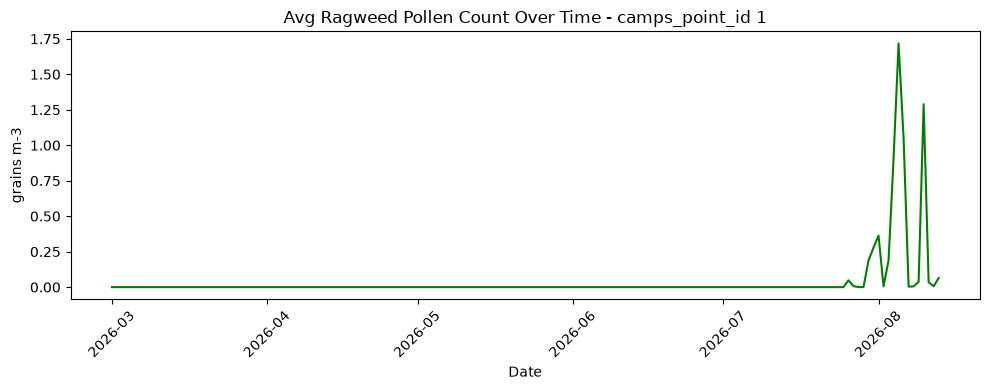

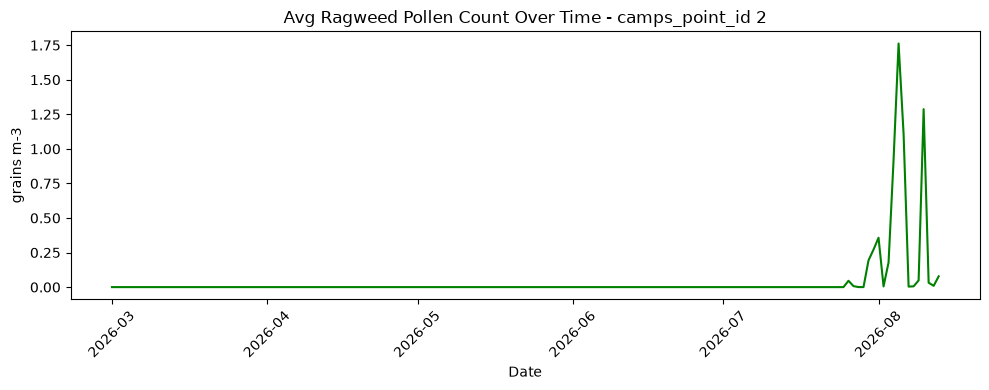

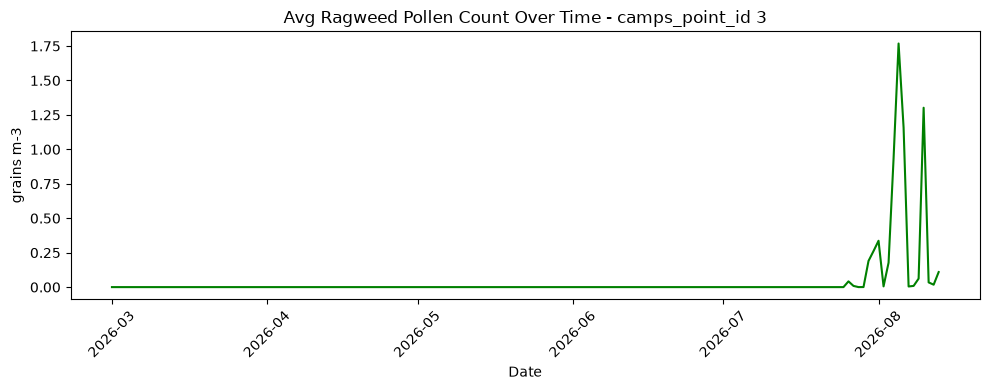

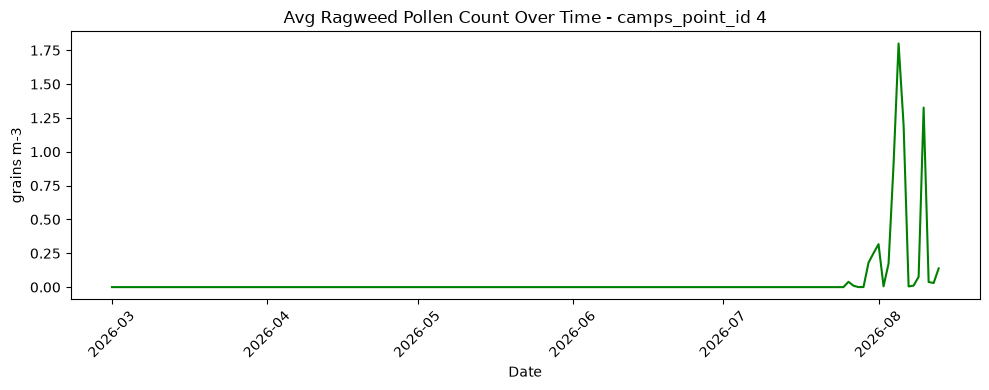

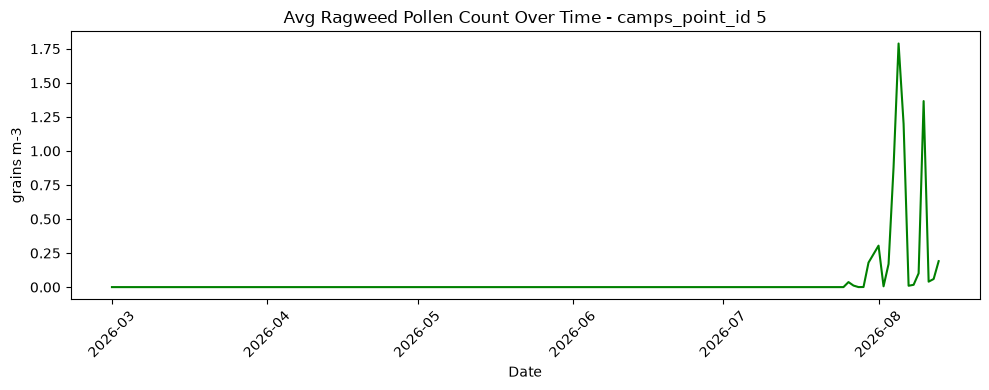

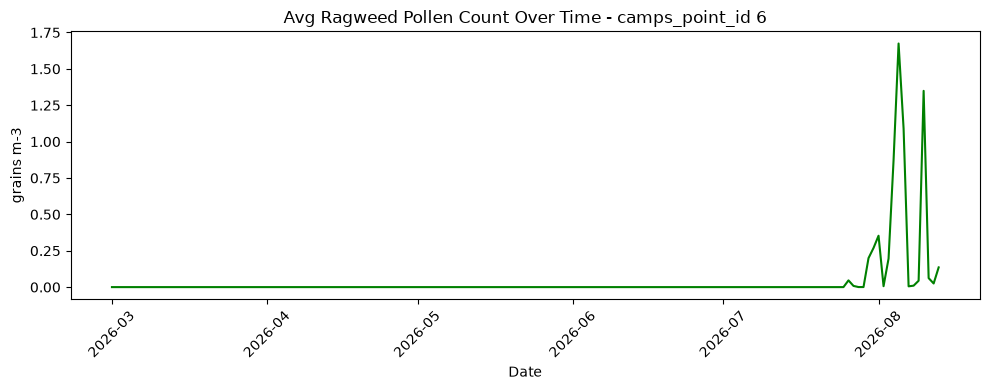

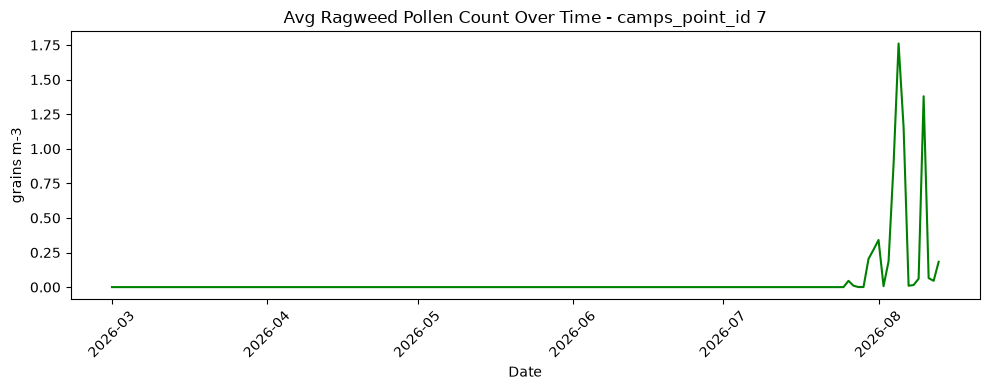

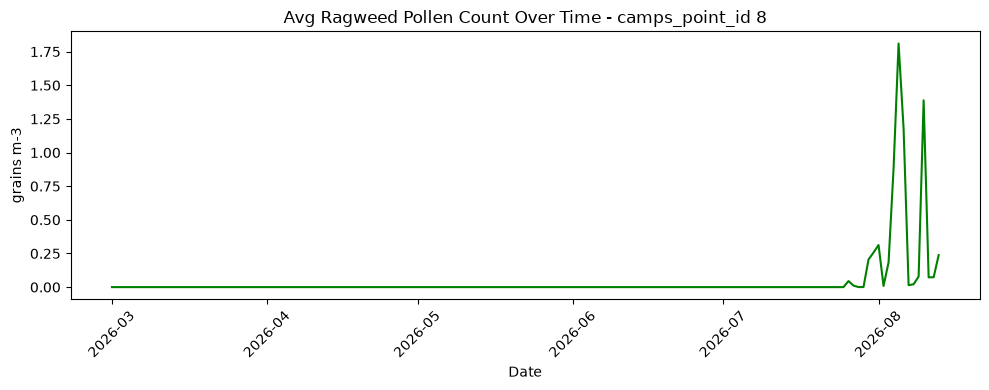

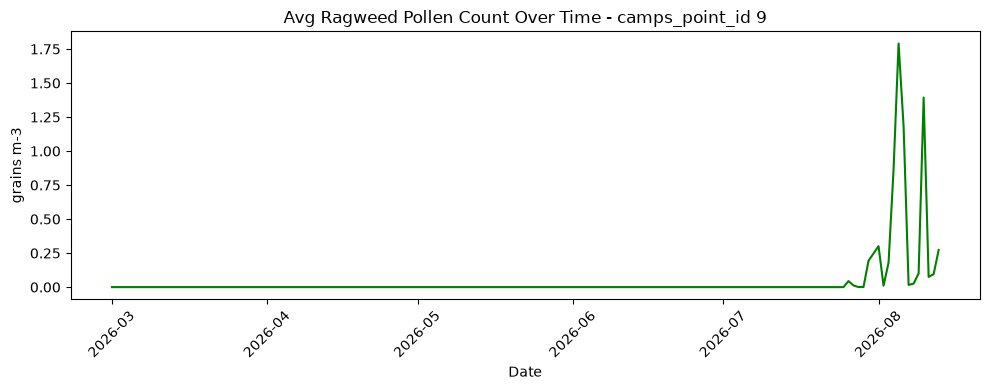

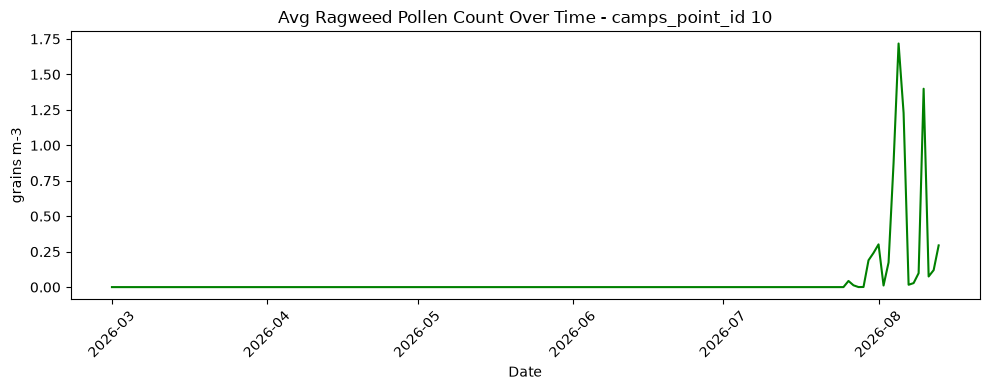

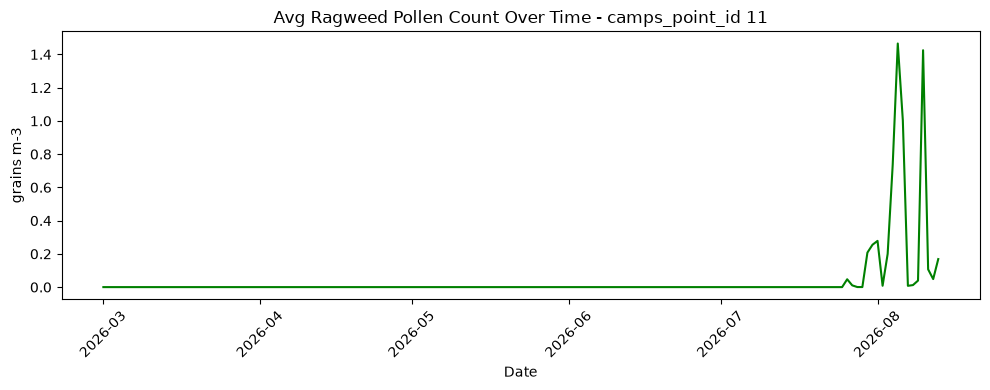

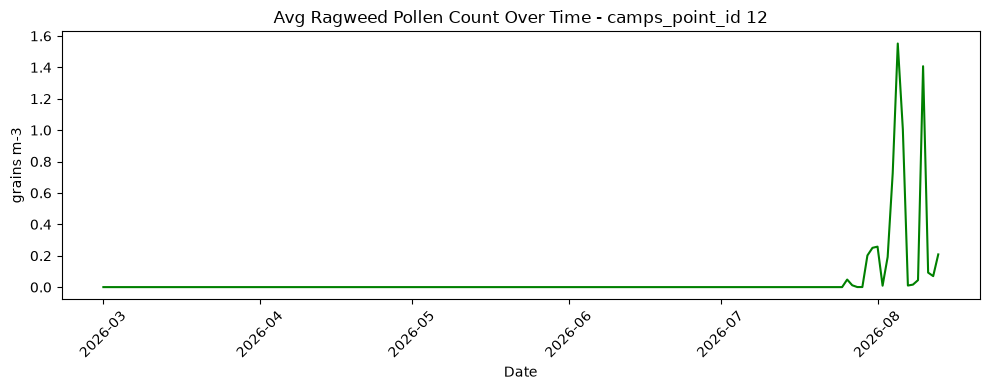

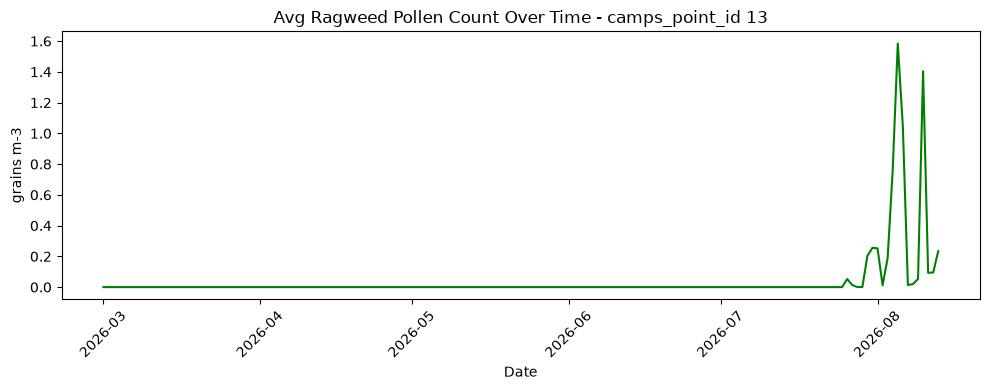

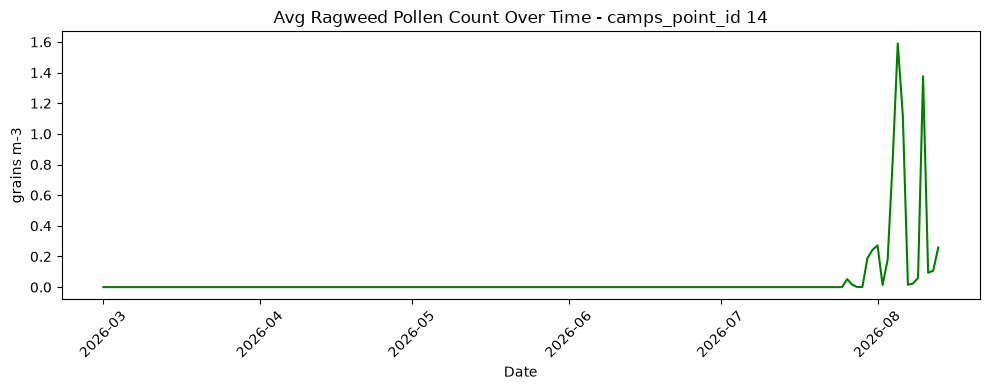

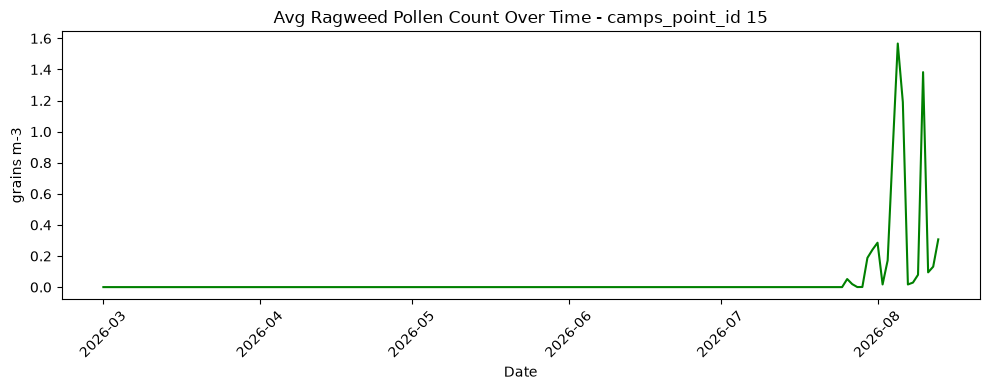

In [7]:
%matplotlib inline

site_ids = sorted(pd.to_numeric(df['camps_point_id'], errors='coerce').dropna().astype(int).unique())

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['ragweed_pollen']
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(site_series.index, site_series.values, color='g')
    plt.title(f"Avg Ragweed Pollen Count Over Time - camps_point_id {site_id}")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.ylabel("grains m-3")
    plt.tight_layout()
    plt.show()

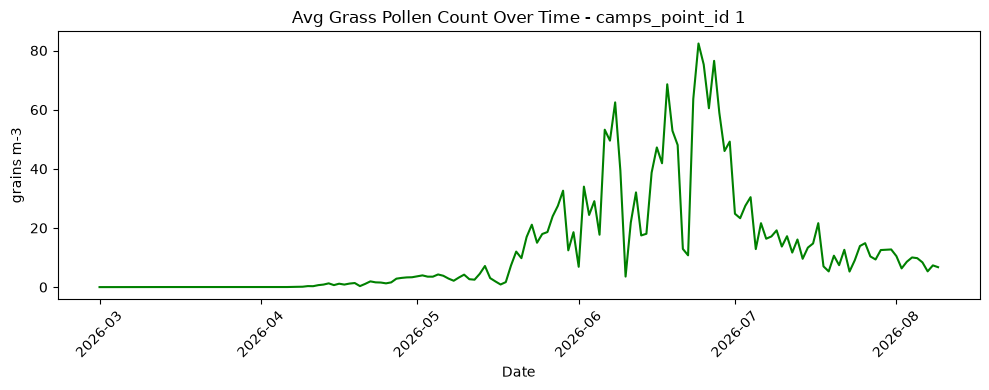

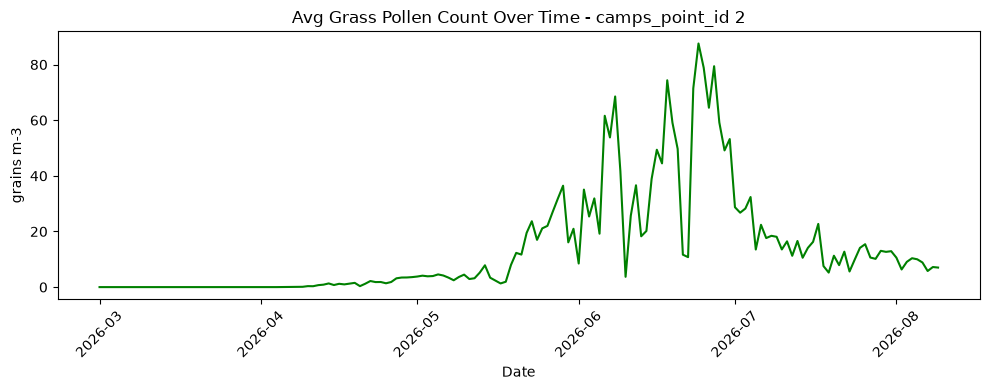

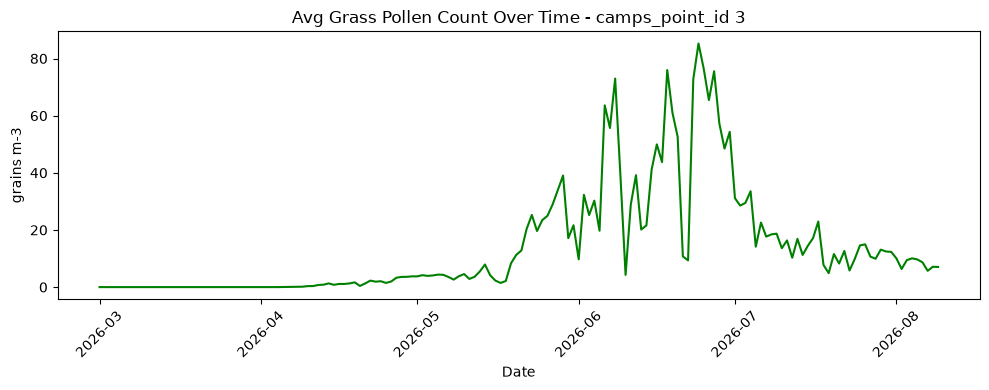

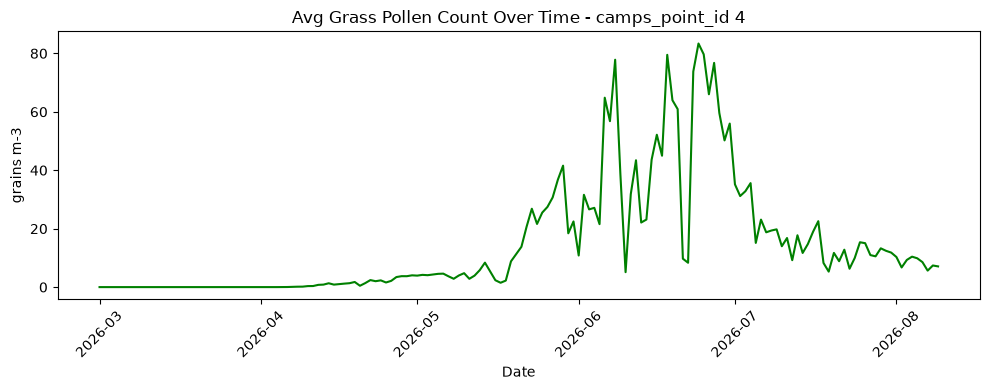

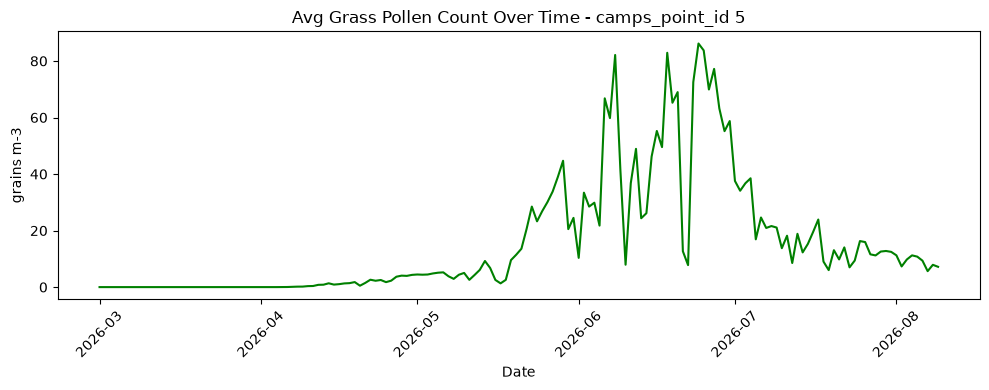

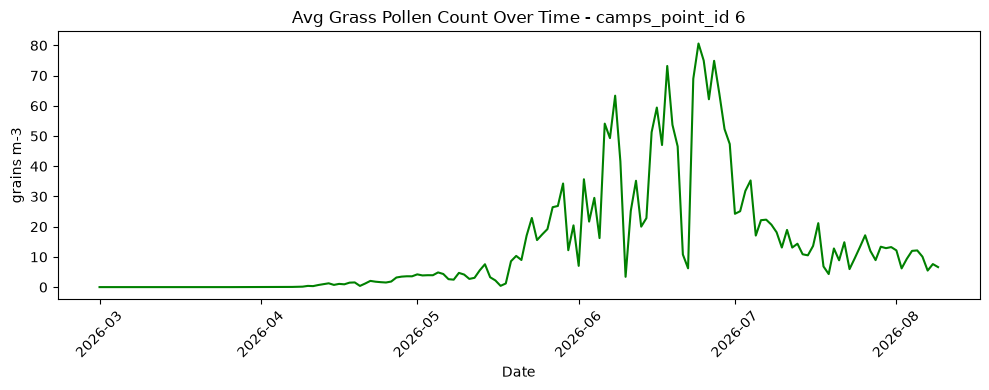

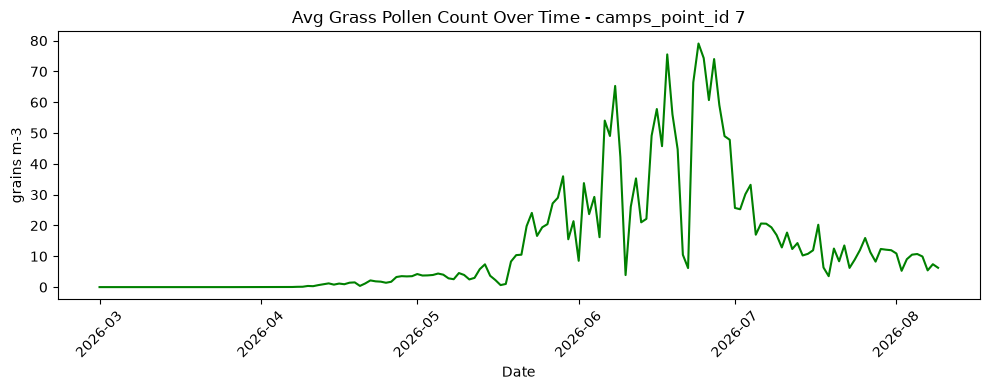

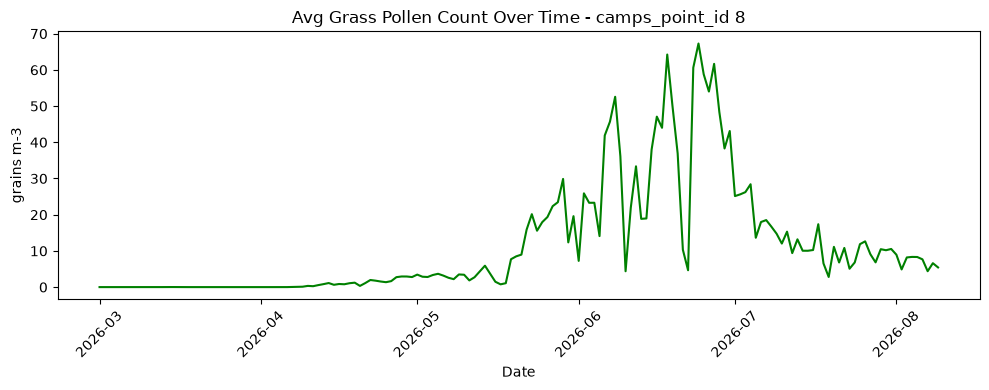

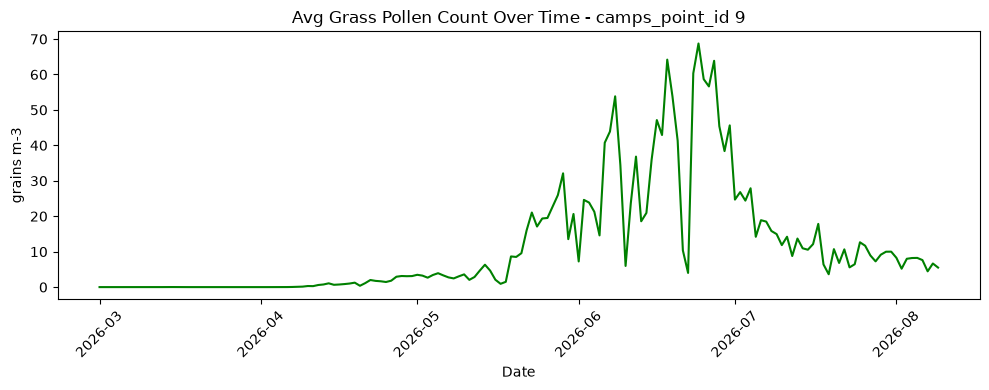

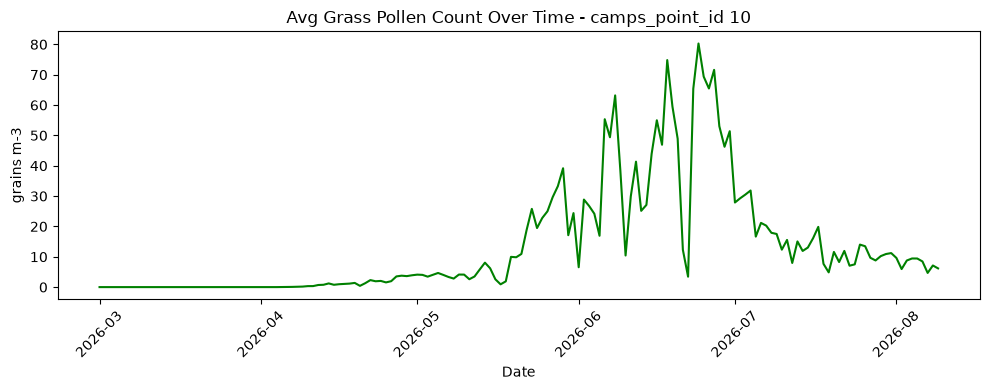

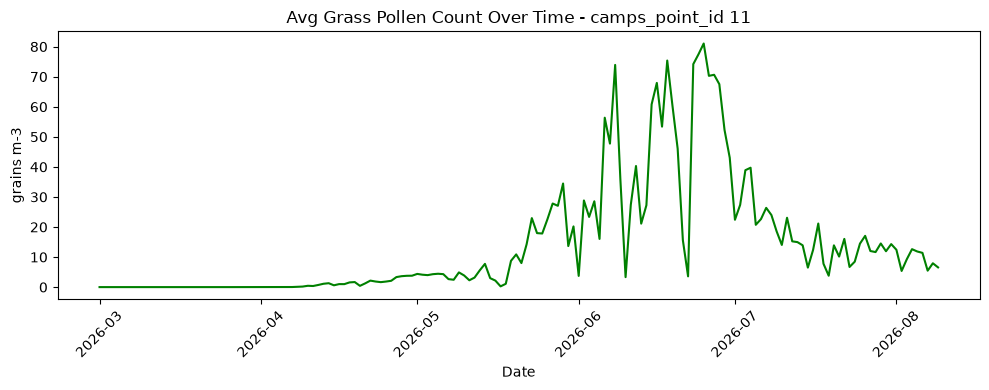

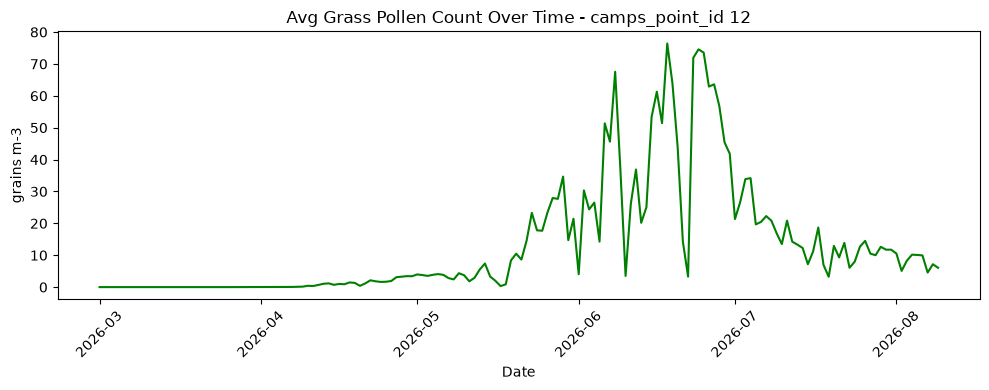

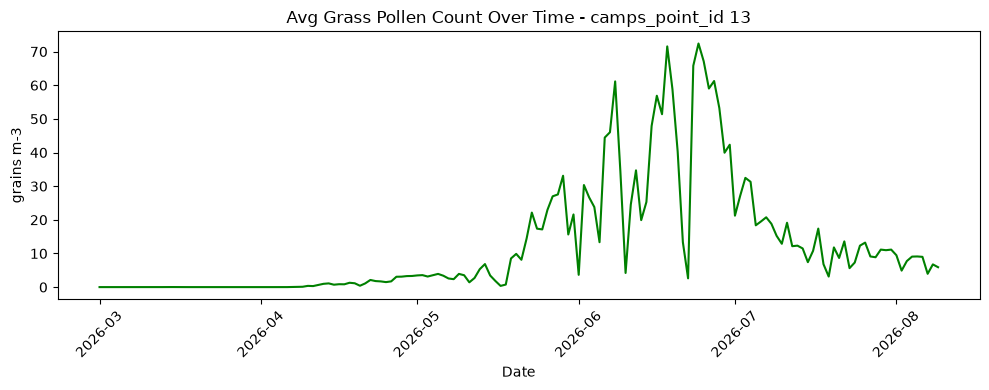

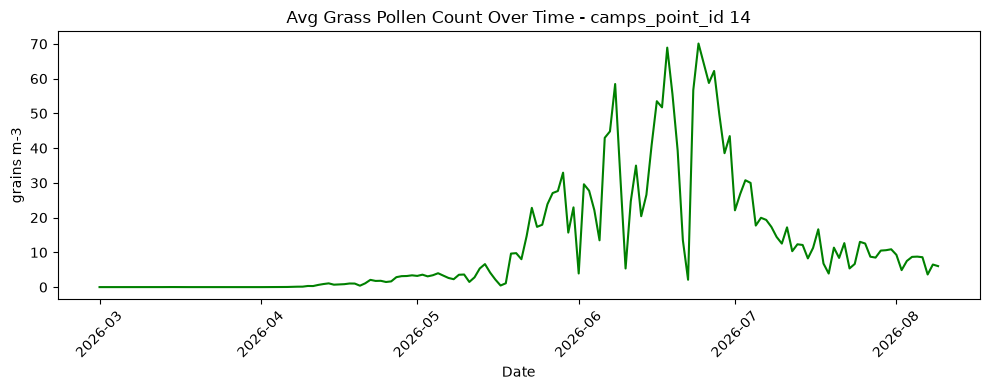

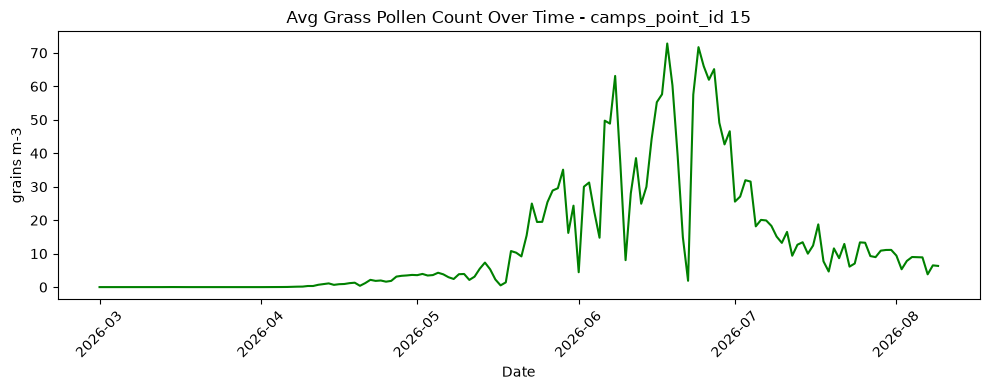

In [9]:
%matplotlib inline

site_ids = sorted(pd.to_numeric(df['camps_point_id'], errors='coerce').dropna().astype(int).unique())

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(site_series.index, site_series.values, color='g')
    plt.title(f"Avg Grass Pollen Count Over Time - camps_point_id {site_id}")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.ylabel("grains m-3")
    plt.tight_layout()
    plt.show()

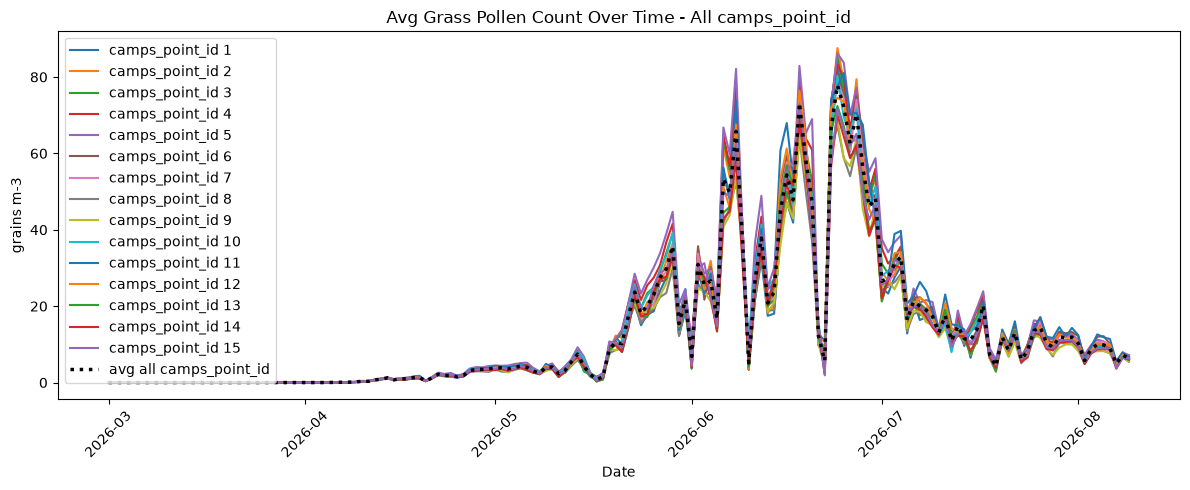

In [10]:
%matplotlib inline

plt.figure(figsize=(12, 5))

overall_avg = (
    df_grouped.groupby(level='fdate')['grass_pollen']
    .mean()
    .sort_index()
)

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.plot(
        site_series.index,
        site_series.values,
        label=f'camps_point_id {site_id}',
        zorder=1
    )

plt.plot(
    overall_avg.index,
    overall_avg.values,
    label='avg all camps_point_id',
    linewidth=2.5,
    color='black',
    linestyle=':',
    zorder=2
)

plt.title('Avg Grass Pollen Count Over Time - All camps_point_id')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('grains m-3')
plt.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))
plt.tight_layout()
plt.show()

In [ ]:
df_grouped_time = (
    df.groupby(['fdate', 'ftime'], as_index=False)[
        ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
    ].mean()
)
df_grouped_time.tail(10)


,fdate,ftime,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
3614,2026-07-29,14:00:00,0.000,0.000,9.300,14.179,0.000,0.000,23.479
3615,2026-07-29,15:00:00,0.000,0.000,9.914,14.889,0.000,0.000,24.803
3616,2026-07-29,16:00:00,0.000,0.000,10.639,15.898,0.000,0.000,26.538
3617,2026-07-29,17:00:00,0.000,0.000,12.008,19.599,0.000,0.000,31.607
3618,2026-07-29,18:00:00,0.000,0.000,14.282,28.990,0.000,0.000,43.272
3619,2026-07-29,19:00:00,0.000,0.000,16.103,35.671,0.000,0.000,51.774
3620,2026-07-29,20:00:00,0.000,0.000,14.276,33.777,0.000,0.000,48.054
3621,2026-07-29,21:00:00,0.000,0.000,14.350,31.669,0.000,0.000,46.019
3622,2026-07-29,22:00:00,0.000,0.000,14.016,30.283,0.000,0.000,44.299
3623,2026-07-29,23:00:00,0.000,0.000,13.541,28.776,0.000,0.000,42.317


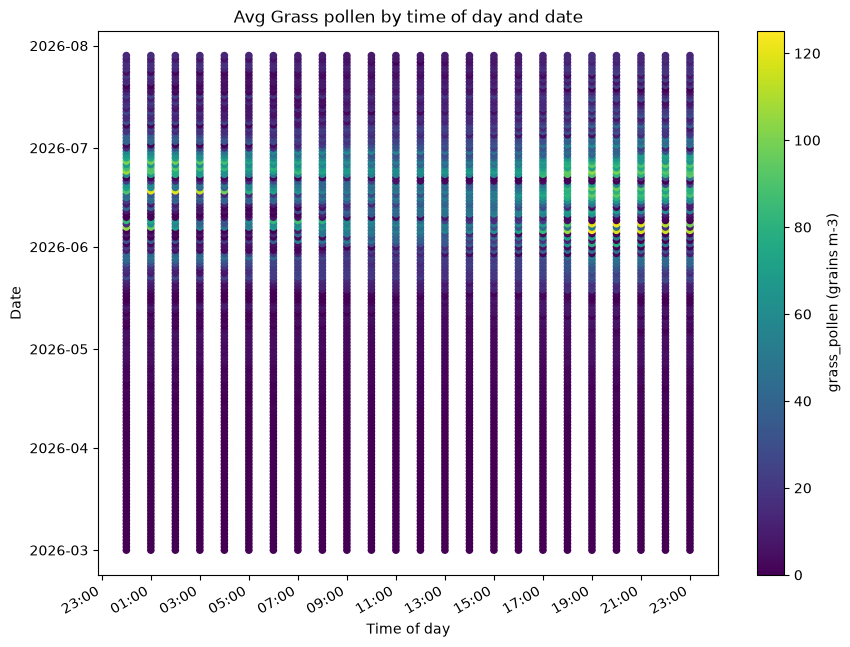

In [11]:
# Scatter plot: x = ftime (time of day), y = fdate (date), color = grass_pollen

ftimes = pd.to_datetime(df_grouped_time['ftime'].astype(str), format='%H:%M:%S', errors='coerce')
fdates = df_grouped_time['fdate']

plt.figure(figsize=(10, 8))
sc = plt.scatter(ftimes, fdates, c=df_grouped_time['grass_pollen'], cmap='viridis', s=20)
plt.colorbar(sc, label='grass_pollen (grains m-3)')
plt.xlabel('Time of day')
plt.ylabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()
plt.title(f'Avg Grass pollen by time of day and date')
plt.show()


In [12]:
engine_render = create_engine(get_database_render_url(), pool_pre_ping=True)
df_synop = pd.read_sql(
    """SELECT * FROM public.synop_data
    ORDER BY date DESC, measurement_hour ASC """,
    engine_render
)

df_synop.head()

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,12566,2026-07-29,0,2026-07-29 01:00:43.107662,2026-07-29 01:00:43.104714,Kraków,11.700,1.000,60,88.000,7.200,1024.300
1,12566,2026-07-29,1,2026-07-29 02:01:11.288890,2026-07-29 02:01:11.287557,Kraków,11.500,1.000,260,88.000,7.200,1024.500
2,12566,2026-07-29,2,2026-07-29 03:00:50.332484,2026-07-29 03:00:50.331234,Kraków,10.700,1.000,270,92.200,7.200,1024.600
3,12566,2026-07-29,3,2026-07-29 04:00:42.122664,2026-07-29 04:00:42.120178,Kraków,10.500,1.000,20,92.800,7.200,1024.700
4,12566,2026-07-29,4,2026-07-29 05:00:32.339691,2026-07-29 05:00:32.337108,Kraków,11.500,0.000,0,83.900,7.200,1024.800


In [13]:
df_synop.dtypes

station_id                    int64
date                         object
measurement_hour              int64
date_add             datetime64[us]
date_update          datetime64[us]
station_name                    str
temperature                 float64
wind_speed                  float64
wind_direction                int64
relative_humidity           float64
rainfall_sum                float64
pressure                    float64
dtype: object

In [14]:
df_synop['date'] = pd.to_datetime(df_synop['date'], format='%Y-%m-%d')
df_synop['measurement_hour_dt'] = df_synop['date'] + pd.to_timedelta(df_synop['measurement_hour'], unit='h')
df_synop['measurement_hour'] = df_synop['measurement_hour_dt'].dt.time

df_synop['date_N_h_ahead'] = df_synop['measurement_hour_dt'] + pd.Timedelta(hours=12)

In [15]:
df_synop.head(5)

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,measurement_hour_dt,date_N_h_ahead
0,12566,2026-07-29,00:00:00,2026-07-29 01:00:43.107662,2026-07-29 01:00:43.104714,Kraków,11.700,1.000,60,88.000,7.200,1024.300,2026-07-29 00:00:00,2026-07-29 12:00:00
1,12566,2026-07-29,01:00:00,2026-07-29 02:01:11.288890,2026-07-29 02:01:11.287557,Kraków,11.500,1.000,260,88.000,7.200,1024.500,2026-07-29 01:00:00,2026-07-29 13:00:00
2,12566,2026-07-29,02:00:00,2026-07-29 03:00:50.332484,2026-07-29 03:00:50.331234,Kraków,10.700,1.000,270,92.200,7.200,1024.600,2026-07-29 02:00:00,2026-07-29 14:00:00
3,12566,2026-07-29,03:00:00,2026-07-29 04:00:42.122664,2026-07-29 04:00:42.120178,Kraków,10.500,1.000,20,92.800,7.200,1024.700,2026-07-29 03:00:00,2026-07-29 15:00:00
4,12566,2026-07-29,04:00:00,2026-07-29 05:00:32.339691,2026-07-29 05:00:32.337108,Kraków,11.500,0.000,0,83.900,7.200,1024.800,2026-07-29 04:00:00,2026-07-29 16:00:00


In [16]:
df_synop_filtered = df_synop[['date', 'date_N_h_ahead', 'measurement_hour', 'measurement_hour_dt', 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].copy()
df_synop_filtered.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,2026-07-29,2026-07-29 12:00:00,00:00:00,2026-07-29 00:00:00,11.700,1.000,60,88.000,7.200,1024.300
1,2026-07-29,2026-07-29 13:00:00,01:00:00,2026-07-29 01:00:00,11.500,1.000,260,88.000,7.200,1024.500
2,2026-07-29,2026-07-29 14:00:00,02:00:00,2026-07-29 02:00:00,10.700,1.000,270,92.200,7.200,1024.600
3,2026-07-29,2026-07-29 15:00:00,03:00:00,2026-07-29 03:00:00,10.500,1.000,20,92.800,7.200,1024.700
4,2026-07-29,2026-07-29 16:00:00,04:00:00,2026-07-29 04:00:00,11.500,0.000,0,83.900,7.200,1024.800
5,2026-07-29,2026-07-29 17:00:00,05:00:00,2026-07-29 05:00:00,13.500,1.000,250,79.600,7.200,1024.600
6,2026-07-29,2026-07-29 18:00:00,06:00:00,2026-07-29 06:00:00,17.400,1.000,200,63.400,0.000,1024.200
7,2026-07-29,2026-07-29 19:00:00,07:00:00,2026-07-29 07:00:00,18.700,0.000,0,62.400,0.000,1024.100
8,2026-07-29,2026-07-29 20:00:00,08:00:00,2026-07-29 08:00:00,21.700,1.000,120,54.400,0.000,1023.900
9,2026-07-29,2026-07-29 21:00:00,09:00:00,2026-07-29 09:00:00,23.400,1.000,360,42.200,0.000,1023.800


In [17]:
df_synop_filtered['date_date_ahead'] = df_synop_filtered['date_N_h_ahead'].dt.date.copy()
df_synop_filtered['time_date_ahead'] = df_synop_filtered['date_N_h_ahead'].dt.time.copy()
df_synop_filtered['date_date_ahead'] = pd.to_datetime(df_synop_filtered['date_date_ahead'], format='%Y-%m-%d')
df_synop_filtered.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead
0,2026-07-29,2026-07-29 12:00:00,00:00:00,2026-07-29 00:00:00,11.700,1.000,60,88.000,7.200,1024.300,2026-07-29,12:00:00
1,2026-07-29,2026-07-29 13:00:00,01:00:00,2026-07-29 01:00:00,11.500,1.000,260,88.000,7.200,1024.500,2026-07-29,13:00:00
2,2026-07-29,2026-07-29 14:00:00,02:00:00,2026-07-29 02:00:00,10.700,1.000,270,92.200,7.200,1024.600,2026-07-29,14:00:00
3,2026-07-29,2026-07-29 15:00:00,03:00:00,2026-07-29 03:00:00,10.500,1.000,20,92.800,7.200,1024.700,2026-07-29,15:00:00
4,2026-07-29,2026-07-29 16:00:00,04:00:00,2026-07-29 04:00:00,11.500,0.000,0,83.900,7.200,1024.800,2026-07-29,16:00:00
5,2026-07-29,2026-07-29 17:00:00,05:00:00,2026-07-29 05:00:00,13.500,1.000,250,79.600,7.200,1024.600,2026-07-29,17:00:00
6,2026-07-29,2026-07-29 18:00:00,06:00:00,2026-07-29 06:00:00,17.400,1.000,200,63.400,0.000,1024.200,2026-07-29,18:00:00
7,2026-07-29,2026-07-29 19:00:00,07:00:00,2026-07-29 07:00:00,18.700,0.000,0,62.400,0.000,1024.100,2026-07-29,19:00:00
8,2026-07-29,2026-07-29 20:00:00,08:00:00,2026-07-29 08:00:00,21.700,1.000,120,54.400,0.000,1023.900,2026-07-29,20:00:00
9,2026-07-29,2026-07-29 21:00:00,09:00:00,2026-07-29 09:00:00,23.400,1.000,360,42.200,0.000,1023.800,2026-07-29,21:00:00


In [18]:
df_synop_mean_by_date = df_synop_filtered.groupby('date', as_index=False)[[ 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].mean()
df_synop_mean_by_date.tail()

,date,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
134,2026-07-25,18.158,1.583,195.417,62.600,4.775,1012.438
135,2026-07-26,21.275,2.542,155.417,59.871,0.200,1006.488
136,2026-07-27,19.004,3.625,246.250,77.138,2.250,1009.908
137,2026-07-28,17.775,4.042,236.250,65.454,6.150,1021.200
138,2026-07-29,15.060,0.800,154.000,74.690,4.320,1024.350


In [19]:
df_merged = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date', 'ftime': 'measurement_hour'}),
    on=['date', 'measurement_hour'],
    how='left'
)
df_merged.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen
0,2026-07-29,2026-07-29 12:00:00,00:00:00,2026-07-29 00:00:00,11.700,1.000,60,88.000,7.200,1024.300,2026-07-29,12:00:00,14.631
1,2026-07-29,2026-07-29 13:00:00,01:00:00,2026-07-29 01:00:00,11.500,1.000,260,88.000,7.200,1024.500,2026-07-29,13:00:00,15.462
2,2026-07-29,2026-07-29 14:00:00,02:00:00,2026-07-29 02:00:00,10.700,1.000,270,92.200,7.200,1024.600,2026-07-29,14:00:00,14.883
3,2026-07-29,2026-07-29 15:00:00,03:00:00,2026-07-29 03:00:00,10.500,1.000,20,92.800,7.200,1024.700,2026-07-29,15:00:00,13.892
4,2026-07-29,2026-07-29 16:00:00,04:00:00,2026-07-29 04:00:00,11.500,0.000,0,83.900,7.200,1024.800,2026-07-29,16:00:00,13.502
5,2026-07-29,2026-07-29 17:00:00,05:00:00,2026-07-29 05:00:00,13.500,1.000,250,79.600,7.200,1024.600,2026-07-29,17:00:00,12.984
6,2026-07-29,2026-07-29 18:00:00,06:00:00,2026-07-29 06:00:00,17.400,1.000,200,63.400,0.000,1024.200,2026-07-29,18:00:00,11.286
7,2026-07-29,2026-07-29 19:00:00,07:00:00,2026-07-29 07:00:00,18.700,0.000,0,62.400,0.000,1024.100,2026-07-29,19:00:00,10.750
8,2026-07-29,2026-07-29 20:00:00,08:00:00,2026-07-29 08:00:00,21.700,1.000,120,54.400,0.000,1023.900,2026-07-29,20:00:00,10.143
9,2026-07-29,2026-07-29 21:00:00,09:00:00,2026-07-29 09:00:00,23.400,1.000,360,42.200,0.000,1023.800,2026-07-29,21:00:00,8.101


In [20]:
df_merged_mean_temperature_by_date = df_merged.merge(
    df_synop_mean_by_date[['date', 'temperature']].rename(columns={'temperature': 'avg_day_temperature'}),
    on=['date'],
    how='left'
)
df_merged_mean_temperature_by_date.head()

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
0,2026-07-29,2026-07-29 12:00:00,00:00:00,2026-07-29 00:00:00,11.700,1.000,60,88.000,7.200,1024.300,2026-07-29,12:00:00,14.631,15.060
1,2026-07-29,2026-07-29 13:00:00,01:00:00,2026-07-29 01:00:00,11.500,1.000,260,88.000,7.200,1024.500,2026-07-29,13:00:00,15.462,15.060
2,2026-07-29,2026-07-29 14:00:00,02:00:00,2026-07-29 02:00:00,10.700,1.000,270,92.200,7.200,1024.600,2026-07-29,14:00:00,14.883,15.060
3,2026-07-29,2026-07-29 15:00:00,03:00:00,2026-07-29 03:00:00,10.500,1.000,20,92.800,7.200,1024.700,2026-07-29,15:00:00,13.892,15.060
4,2026-07-29,2026-07-29 16:00:00,04:00:00,2026-07-29 04:00:00,11.500,0.000,0,83.900,7.200,1024.800,2026-07-29,16:00:00,13.502,15.060


In [21]:
# 5 AM to 9 PM = day, 10 PM to 4 AM = night
df_merged_mean_temperature_by_date['day_night'] = df_merged_mean_temperature_by_date['measurement_hour_dt'].apply(
    lambda x: 'day' if 5 <= x.hour <= 21 else 'night'
)

# Calculate average temperature per day/night period and map it back to each row
avg_day_temp = (
    df_merged_mean_temperature_by_date[df_merged_mean_temperature_by_date['day_night'] == 'day']
    .groupby('date')['temperature']
    .mean()
    .rename('avg_day_light_temperature')
)

avg_night_temp = (
    df_merged_mean_temperature_by_date[df_merged_mean_temperature_by_date['day_night'] == 'night']
    .groupby('date')['temperature']
    .mean()
    .rename('avg_night_temperature')
)

# Add the per-day averages as columns on the existing dataframe
df_merged_mean_temperature_by_date['avg_day_light_temperature'] = (
    df_merged_mean_temperature_by_date['date'].map(avg_day_temp)
)
df_merged_mean_temperature_by_date['avg_night_temperature'] = (
    df_merged_mean_temperature_by_date['date'].map(avg_night_temp)
)

# Add a single column representing the temperature for the current day/night period
# for each row, based on the same mapping logic
df_merged_mean_temperature_by_date['avg_day_night_temperature'] = np.where(
    df_merged_mean_temperature_by_date['day_night'] == 'day',
    df_merged_mean_temperature_by_date['avg_day_light_temperature'],
    df_merged_mean_temperature_by_date['avg_night_temperature']
)
#avg wind_speed
avg_wind_speed = (
    df_merged_mean_temperature_by_date.groupby('date')['wind_speed']
    .mean()
    .rename('avg_wind_speed')
)
df_merged_mean_temperature_by_date['avg_wind_speed'] = (
    df_merged_mean_temperature_by_date['date'].map(avg_wind_speed)
)

df_merged_mean_temperature_by_date[['date', 'measurement_hour_dt', 'day_night', 'temperature', 'avg_day_light_temperature', 'avg_day_temperature', 'avg_night_temperature', 'avg_day_night_temperature', 'avg_wind_speed']].head(24)

,date,measurement_hour_dt,day_night,temperature,avg_day_light_temperature,avg_day_temperature,avg_night_temperature,avg_day_night_temperature,avg_wind_speed
0,2026-07-29,2026-07-29 00:00:00,night,11.700,18.940,15.060,11.180,11.180,0.800
1,2026-07-29,2026-07-29 01:00:00,night,11.500,18.940,15.060,11.180,11.180,0.800
2,2026-07-29,2026-07-29 02:00:00,night,10.700,18.940,15.060,11.180,11.180,0.800
3,2026-07-29,2026-07-29 03:00:00,night,10.500,18.940,15.060,11.180,11.180,0.800
4,2026-07-29,2026-07-29 04:00:00,night,11.500,18.940,15.060,11.180,11.180,0.800
5,2026-07-29,2026-07-29 05:00:00,day,13.500,18.940,15.060,11.180,18.940,0.800
6,2026-07-29,2026-07-29 06:00:00,day,17.400,18.940,15.060,11.180,18.940,0.800
7,2026-07-29,2026-07-29 07:00:00,day,18.700,18.940,15.060,11.180,18.940,0.800
8,2026-07-29,2026-07-29 08:00:00,day,21.700,18.940,15.060,11.180,18.940,0.800
9,2026-07-29,2026-07-29 09:00:00,day,23.400,18.940,15.060,11.180,18.940,0.800


In [22]:
df_merged_mean_temperature_by_date.drop(columns=['avg_day_light_temperature', 'avg_night_temperature'], inplace=True)
df_merged_mean_temperature_by_date.head(24)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
0,2026-07-29,2026-07-29 12:00:00,00:00:00,2026-07-29 00:00:00,11.700,1.000,60,88.000,7.200,1024.300,2026-07-29,12:00:00,14.631,15.060,night,11.180,0.800
1,2026-07-29,2026-07-29 13:00:00,01:00:00,2026-07-29 01:00:00,11.500,1.000,260,88.000,7.200,1024.500,2026-07-29,13:00:00,15.462,15.060,night,11.180,0.800
2,2026-07-29,2026-07-29 14:00:00,02:00:00,2026-07-29 02:00:00,10.700,1.000,270,92.200,7.200,1024.600,2026-07-29,14:00:00,14.883,15.060,night,11.180,0.800
3,2026-07-29,2026-07-29 15:00:00,03:00:00,2026-07-29 03:00:00,10.500,1.000,20,92.800,7.200,1024.700,2026-07-29,15:00:00,13.892,15.060,night,11.180,0.800
4,2026-07-29,2026-07-29 16:00:00,04:00:00,2026-07-29 04:00:00,11.500,0.000,0,83.900,7.200,1024.800,2026-07-29,16:00:00,13.502,15.060,night,11.180,0.800
5,2026-07-29,2026-07-29 17:00:00,05:00:00,2026-07-29 05:00:00,13.500,1.000,250,79.600,7.200,1024.600,2026-07-29,17:00:00,12.984,15.060,day,18.940,0.800
6,2026-07-29,2026-07-29 18:00:00,06:00:00,2026-07-29 06:00:00,17.400,1.000,200,63.400,0.000,1024.200,2026-07-29,18:00:00,11.286,15.060,day,18.940,0.800
7,2026-07-29,2026-07-29 19:00:00,07:00:00,2026-07-29 07:00:00,18.700,0.000,0,62.400,0.000,1024.100,2026-07-29,19:00:00,10.750,15.060,day,18.940,0.800
8,2026-07-29,2026-07-29 20:00:00,08:00:00,2026-07-29 08:00:00,21.700,1.000,120,54.400,0.000,1023.900,2026-07-29,20:00:00,10.143,15.060,day,18.940,0.800
9,2026-07-29,2026-07-29 21:00:00,09:00:00,2026-07-29 09:00:00,23.400,1.000,360,42.200,0.000,1023.800,2026-07-29,21:00:00,8.101,15.060,day,18.940,0.800


In [23]:
df_merged_date_ahead = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date_date_ahead', 'ftime': 'time_date_ahead'}),
    on=['date_date_ahead', 'time_date_ahead'],
    how='left'
)
df_merged_date_ahead.tail(50)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen
3233,2026-03-15,2026-03-15 22:00:00,10:00:00,2026-03-15 10:00:00,17.500,1.000,90,31.500,0.000,1011.700,2026-03-15,22:00:00,0.005
3234,2026-03-15,2026-03-15 23:00:00,11:00:00,2026-03-15 11:00:00,18.800,1.000,180,29.400,0.000,1011.600,2026-03-15,23:00:00,0.005
3235,2026-03-15,2026-03-16 00:00:00,12:00:00,2026-03-15 12:00:00,18.100,3.000,60,28.600,0.000,1011.300,2026-03-16,00:00:00,0.006
3236,2026-03-15,2026-03-16 01:00:00,13:00:00,2026-03-15 13:00:00,17.900,3.000,110,29.600,0.000,1011.300,2026-03-16,01:00:00,0.006
3237,2026-03-15,2026-03-16 02:00:00,14:00:00,2026-03-15 14:00:00,17.000,3.000,60,31.600,0.000,1011.400,2026-03-16,02:00:00,0.006
3238,2026-03-15,2026-03-16 03:00:00,15:00:00,2026-03-15 15:00:00,17.400,3.000,40,28.600,0.000,1011.300,2026-03-16,03:00:00,0.007
3239,2026-03-15,2026-03-16 04:00:00,16:00:00,2026-03-15 16:00:00,16.000,3.000,10,32.500,0.000,1011.800,2026-03-16,04:00:00,0.008
3240,2026-03-15,2026-03-16 05:00:00,17:00:00,2026-03-15 17:00:00,13.800,4.000,330,45.600,0.000,1012.500,2026-03-16,05:00:00,0.009
3241,2026-03-15,2026-03-16 06:00:00,18:00:00,2026-03-15 18:00:00,12.900,5.000,340,50.600,0.000,1013.100,2026-03-16,06:00:00,0.011
3242,2026-03-15,2026-03-16 07:00:00,19:00:00,2026-03-15 19:00:00,11.000,4.000,50,62.500,0.000,1014.000,2026-03-16,07:00:00,0.011


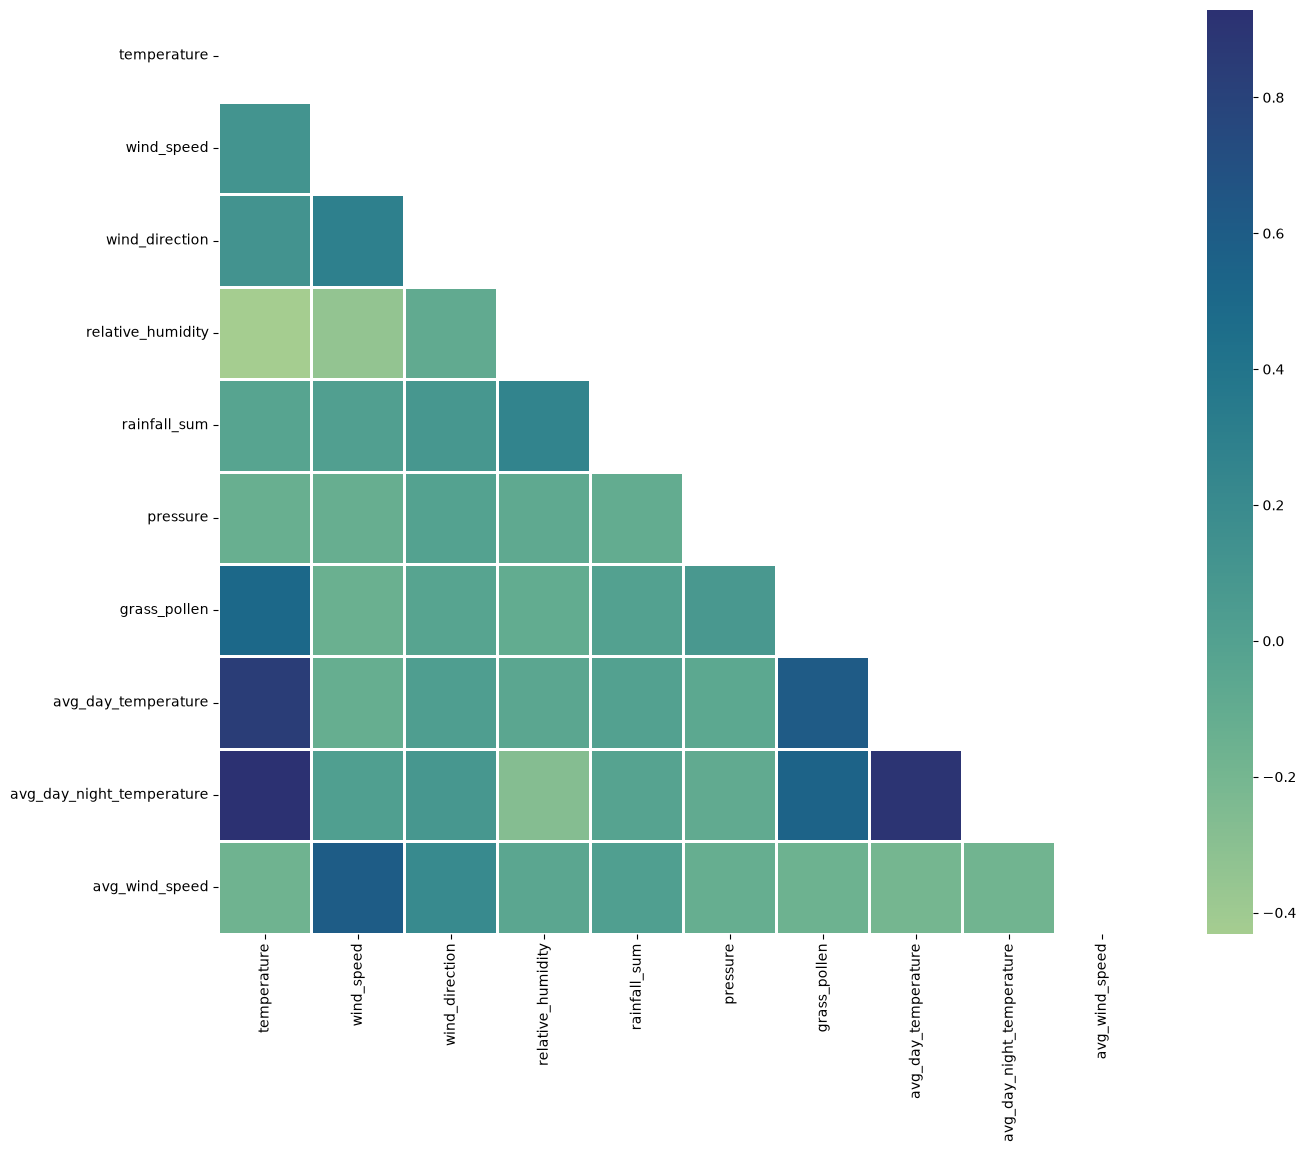

In [24]:
#triangular matrix
num_cols = df_merged_mean_temperature_by_date.select_dtypes(['int', 'float']).columns
corr_data = df_merged_mean_temperature_by_date[num_cols]

corr_coef = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef)
sns.heatmap(corr_coef,linewidth=.8, mask = matrix, cmap="crest");

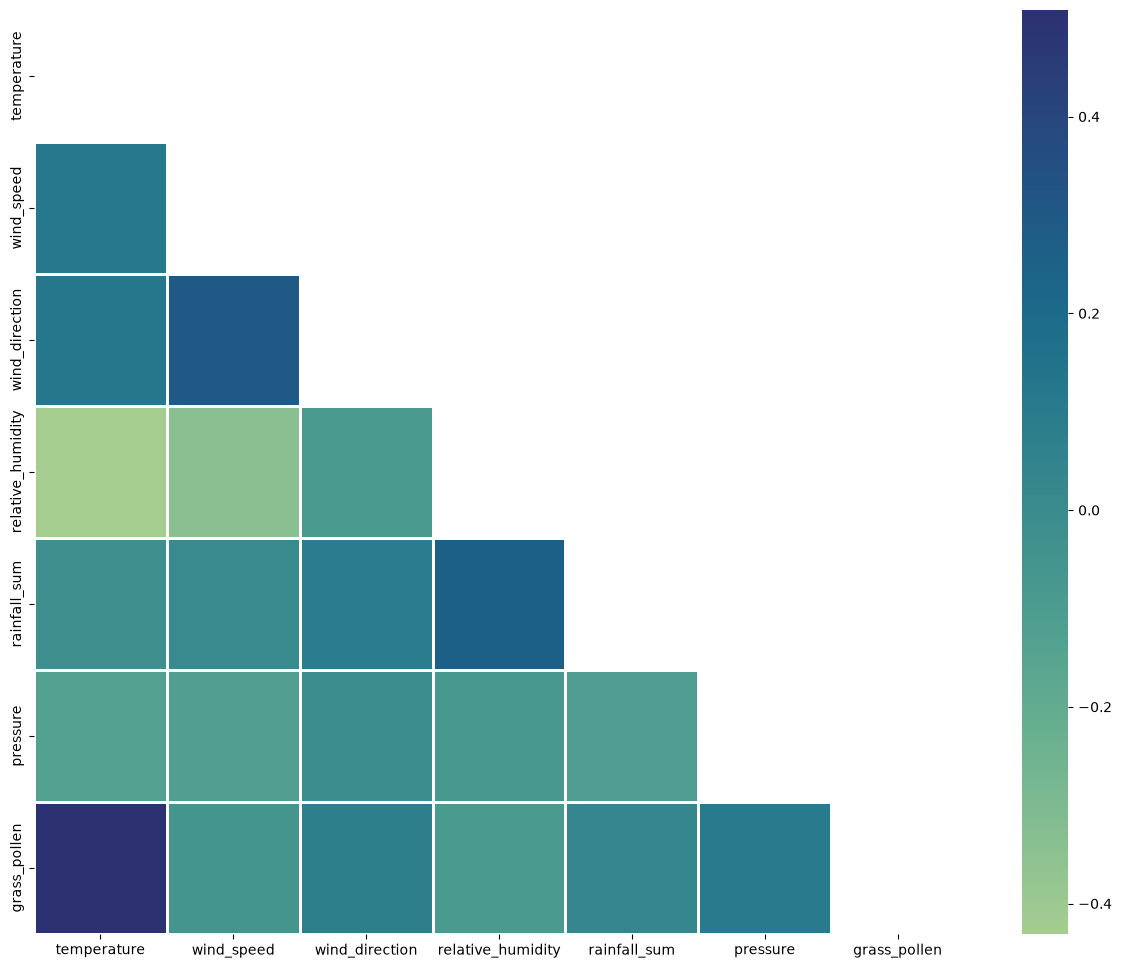

In [25]:
#triangular matrix date ahead
num_cols_date_ahead = df_merged_date_ahead.select_dtypes(['int', 'float']).columns
corr_data = df_merged_date_ahead[num_cols_date_ahead]

corr_coef_date_ahead = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef_date_ahead)
sns.heatmap(corr_coef_date_ahead,linewidth=.8, mask = matrix, cmap="crest");

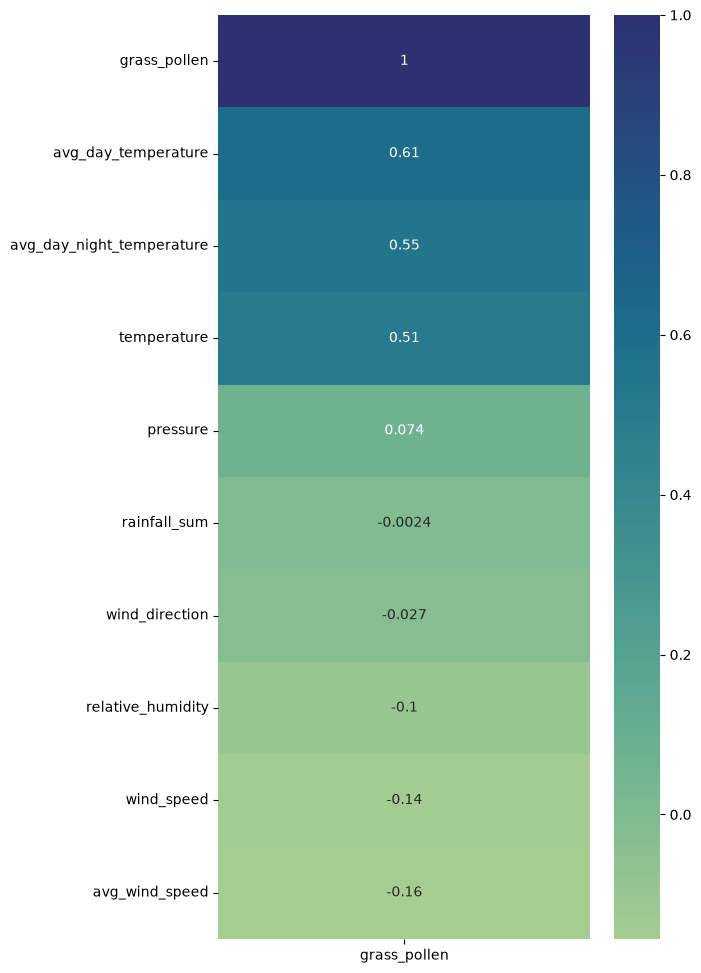

In [26]:
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);

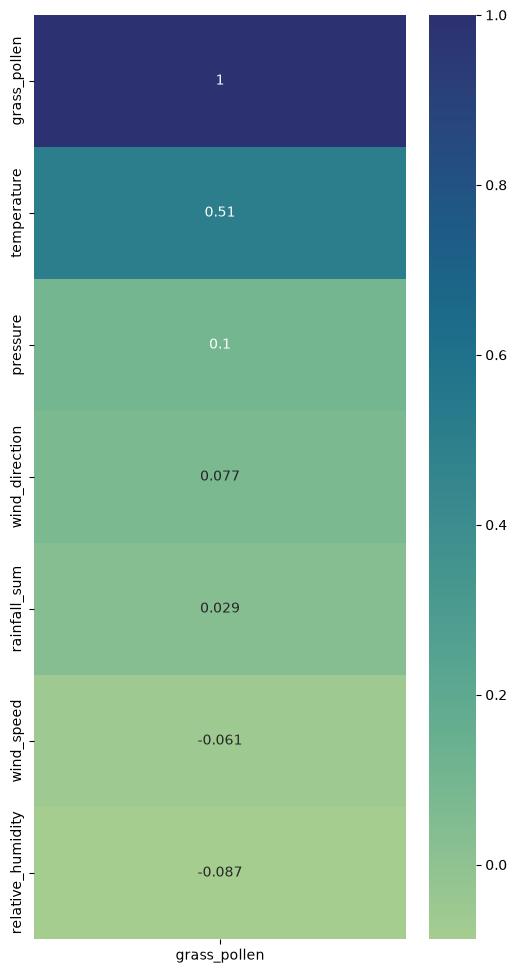

In [27]:
#date ahead
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_date_ahead[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);


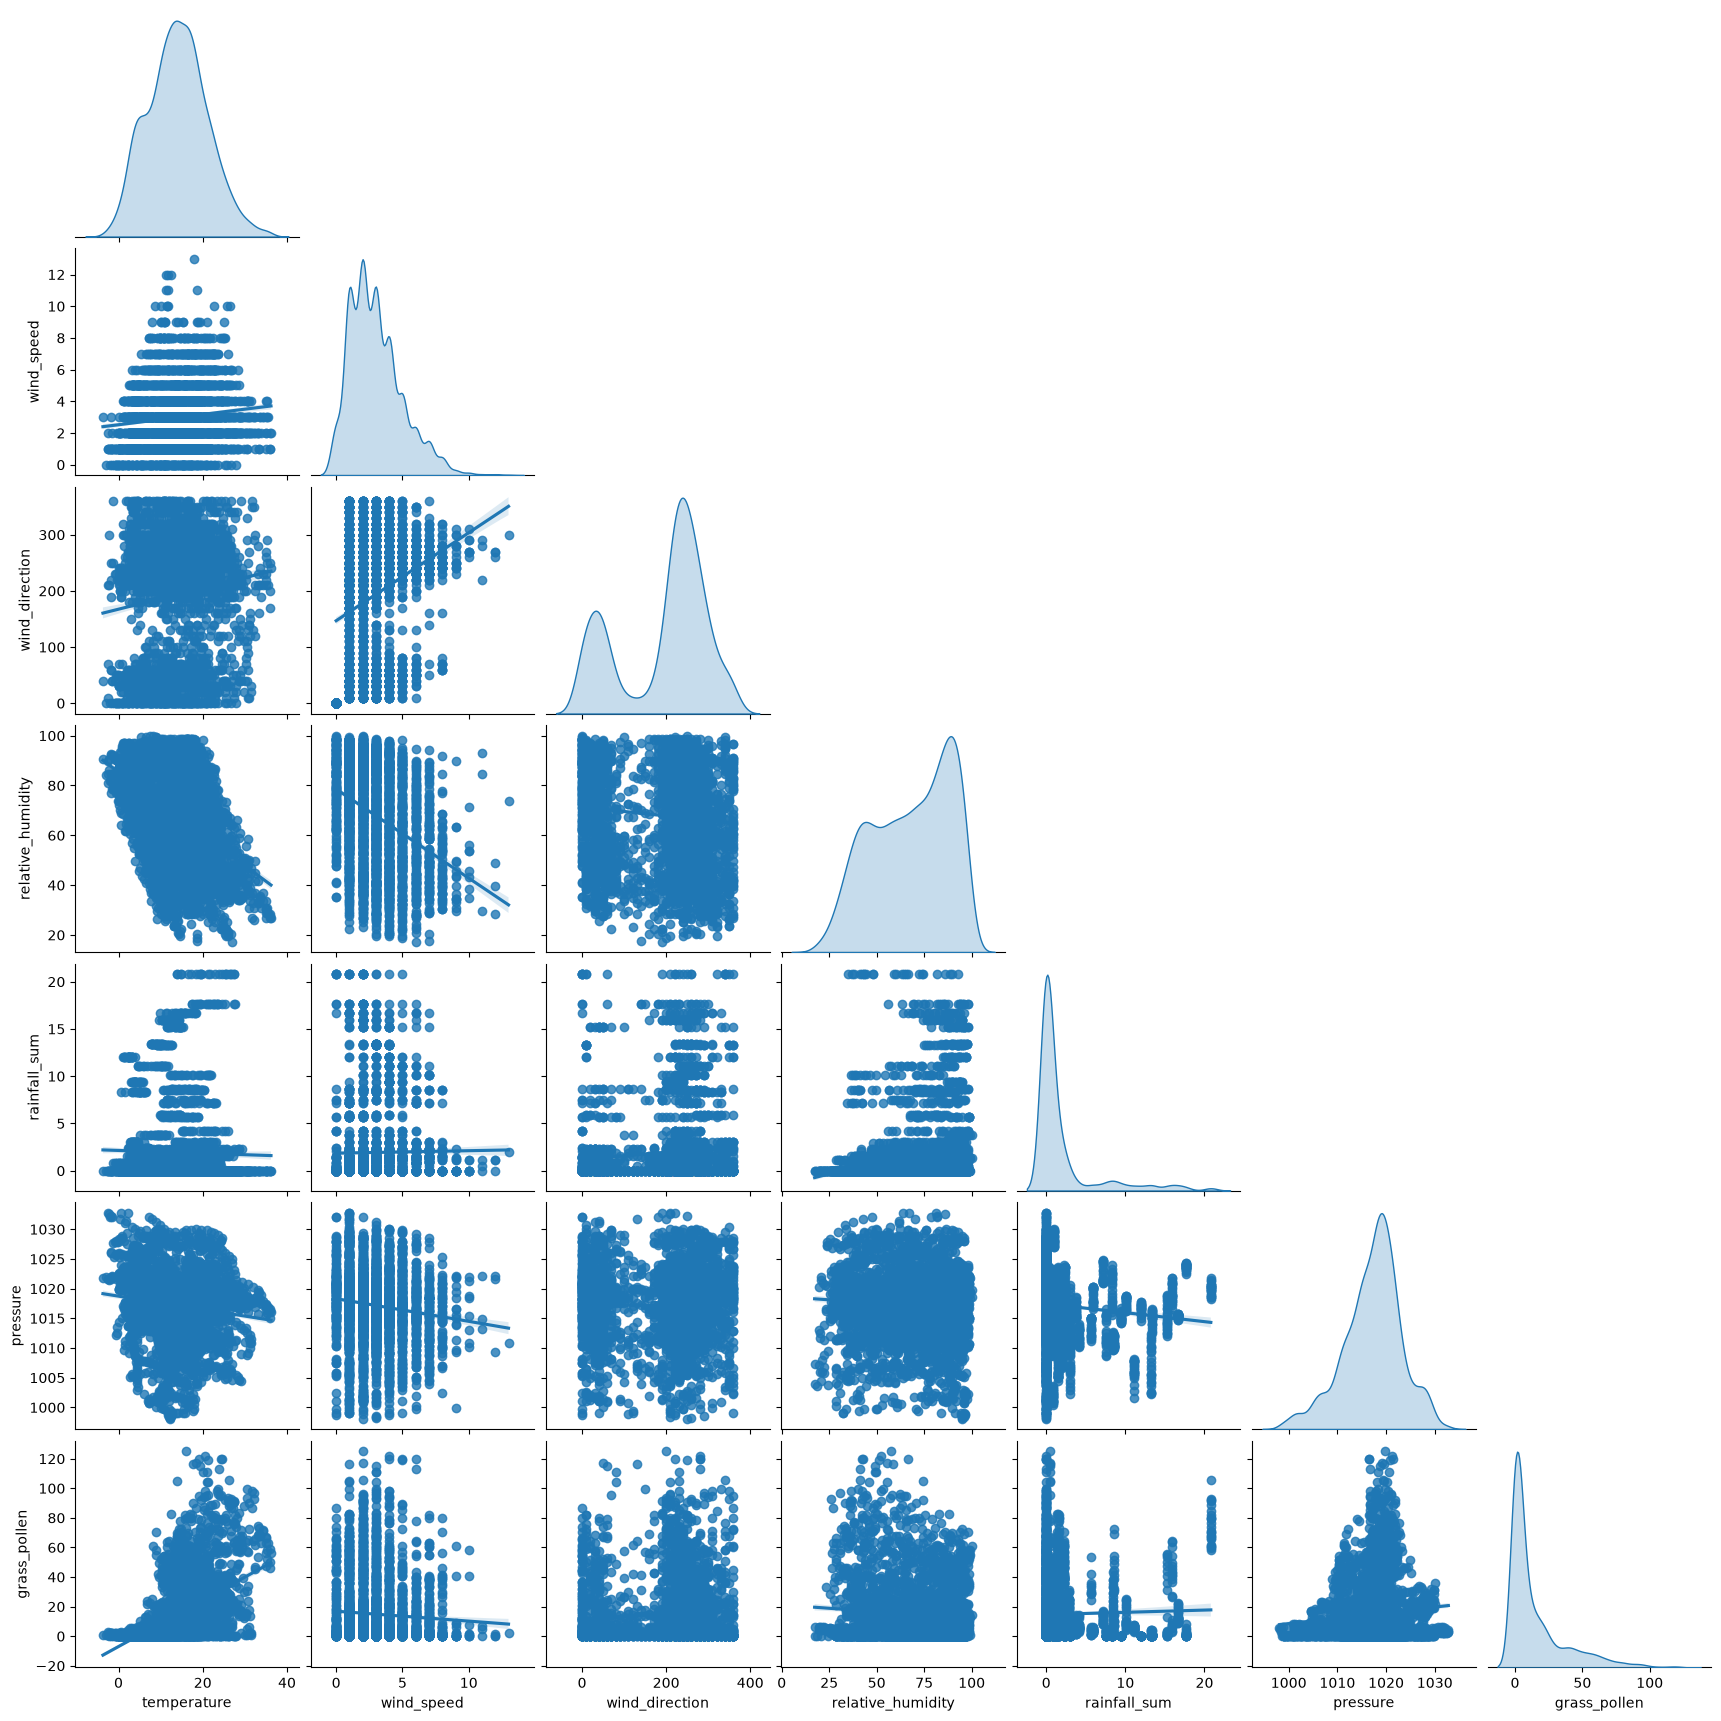

In [28]:
sns.pairplot(corr_data, corner=True, kind='reg', diag_kind='kde')

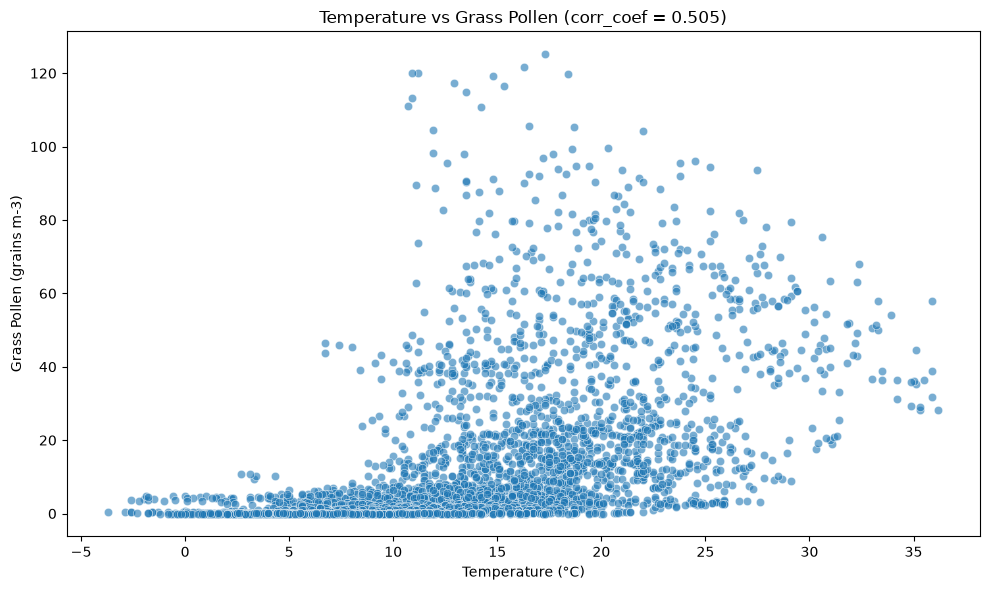

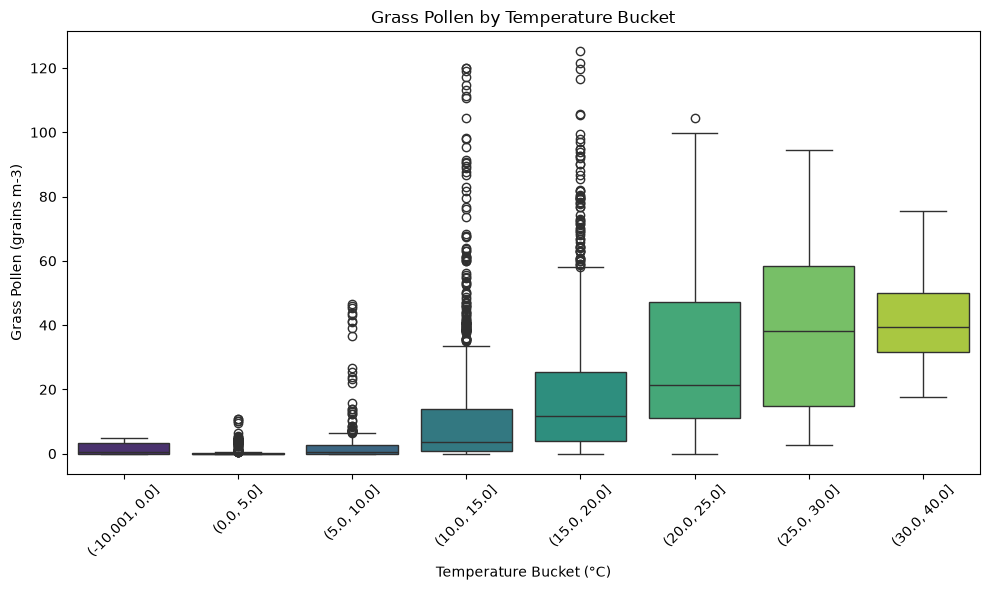

In [29]:
scatter_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x='temperature', y='grass_pollen', alpha=0.6)
#sns.regplot(data=scatter_df, x='temperature', y='grass_pollen', scatter=False, color='black')
plt.title(f'Temperature vs Grass Pollen (corr_coef = {scatter_df[["temperature", "grass_pollen"]].corr().iloc[0, 1]:.3f})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.tight_layout()
plt.show()

bucket_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()
bucket_df['temperature_bucket'] = pd.cut(
    bucket_df['temperature'],
    bins=[-10, 0, 5, 10, 15, 20, 25, 30, 40],
    right=True,
    include_lowest=True
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=bucket_df, x='temperature_bucket', y='grass_pollen', hue='temperature_bucket', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Temperature Bucket')
plt.xlabel('Temperature Bucket (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

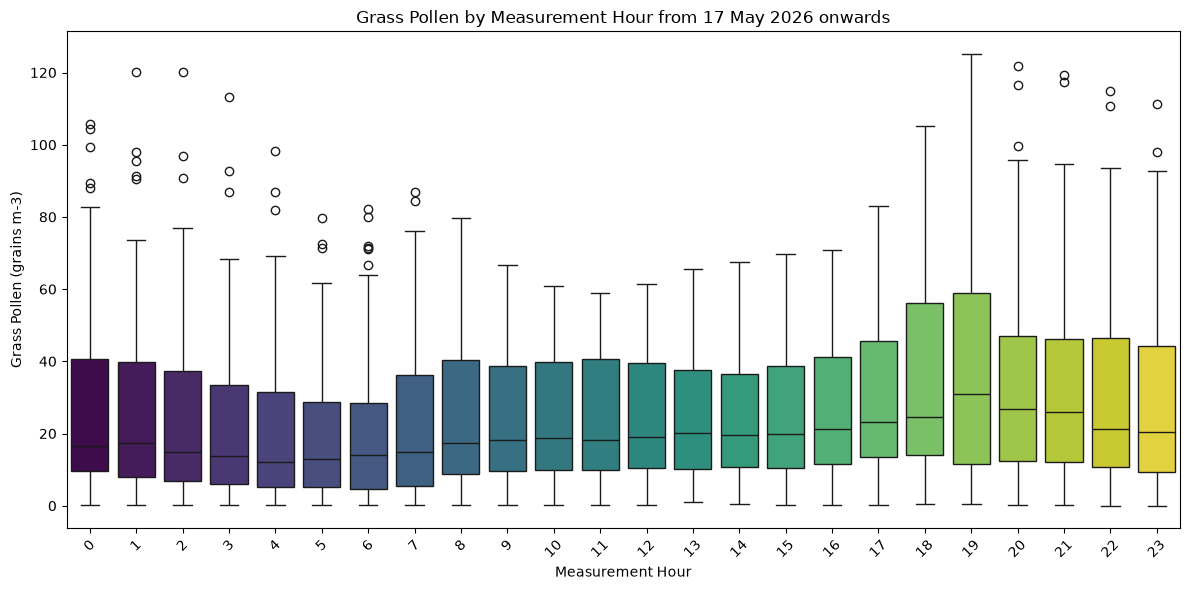

In [30]:
df_merged_from_date = df_merged[df_merged['date'] >= '2026-05-17'].copy()
hourly_df = df_merged_from_date.dropna(subset=['measurement_hour', 'grass_pollen']).copy()
hourly_df['measurement_hour'] = hourly_df['measurement_hour'].apply(lambda h: h.hour)

plt.figure(figsize=(12, 6))
sns.boxplot(data=hourly_df, x='measurement_hour', y='grass_pollen', hue='measurement_hour', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Measurement Hour from 17 May 2026 onwards')
plt.xlabel('Measurement Hour')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
df_merged_from_date_range_1 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-05-28') & (df_merged_mean_temperature_by_date['date'] < '2026-06-05')].copy()
plot_df_1 = df_merged_from_date_range_1.sort_values(['date', 'measurement_hour'])
plot_df_1.head(60)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
1449,2026-05-28,2026-05-28 12:00:00,00:00:00,2026-05-28 00:00:00,12.300,3.000,310,46.600,0.000,1020.100,2026-05-28,12:00:00,40.535,14.425,night,10.186,3.417
1450,2026-05-28,2026-05-28 13:00:00,01:00:00,2026-05-28 01:00:00,11.700,3.000,310,48.500,0.000,1020.100,2026-05-28,13:00:00,40.131,14.425,night,10.186,3.417
1451,2026-05-28,2026-05-28 14:00:00,02:00:00,2026-05-28 02:00:00,8.400,2.000,270,64.700,0.000,1020.600,2026-05-28,14:00:00,39.185,14.425,night,10.186,3.417
1452,2026-05-28,2026-05-28 15:00:00,03:00:00,2026-05-28 03:00:00,9.400,1.000,230,61.700,0.000,1020.800,2026-05-28,15:00:00,36.672,14.425,night,10.186,3.417
1453,2026-05-28,2026-05-28 16:00:00,04:00:00,2026-05-28 04:00:00,10.400,3.000,260,60.700,0.000,1021.200,2026-05-28,16:00:00,32.948,14.425,night,10.186,3.417
1454,2026-05-28,2026-05-28 17:00:00,05:00:00,2026-05-28 05:00:00,12.200,4.000,290,54.500,0.000,1021.400,2026-05-28,17:00:00,28.696,14.425,day,16.171,3.417
1455,2026-05-28,2026-05-28 18:00:00,06:00:00,2026-05-28 06:00:00,13.400,4.000,280,54.400,0.000,1021.700,2026-05-28,18:00:00,24.191,14.425,day,16.171,3.417
1456,2026-05-28,2026-05-28 19:00:00,07:00:00,2026-05-28 07:00:00,14.300,5.000,270,47.400,0.000,1021.800,2026-05-28,19:00:00,21.653,14.425,day,16.171,3.417
1457,2026-05-28,2026-05-28 20:00:00,08:00:00,2026-05-28 08:00:00,15.600,5.000,290,39.400,0.000,1021.700,2026-05-28,20:00:00,19.689,14.425,day,16.171,3.417
1458,2026-05-28,2026-05-28 21:00:00,09:00:00,2026-05-28 09:00:00,16.700,5.000,300,39.400,0.000,1021.700,2026-05-28,21:00:00,18.272,14.425,day,16.171,3.417


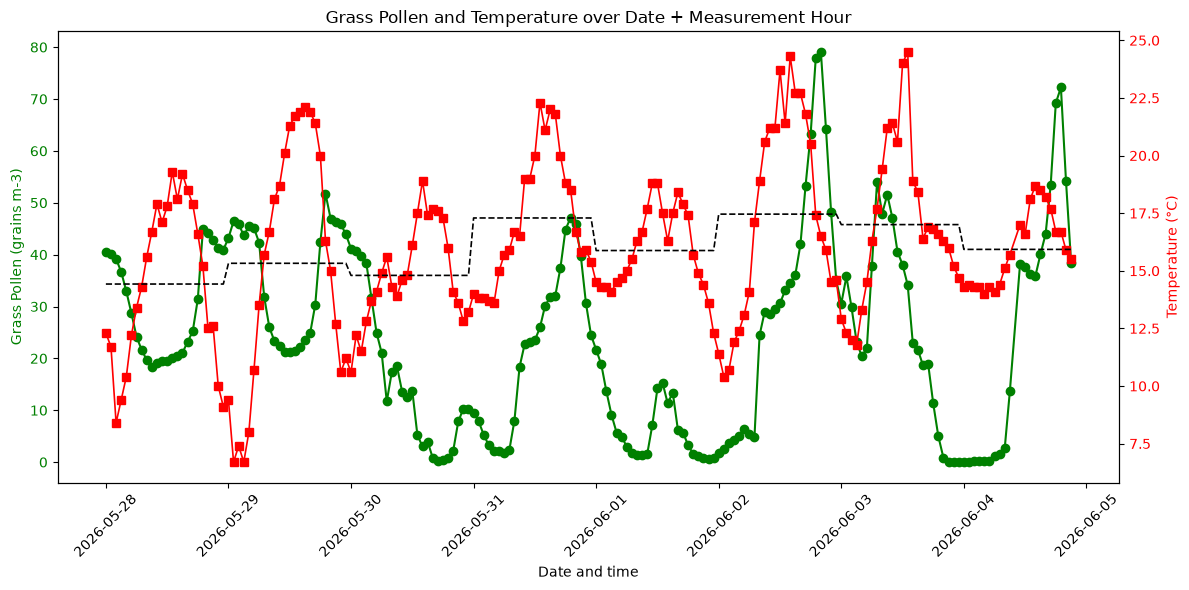

In [32]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
data_3 = plot_df_1['avg_day_temperature']

x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

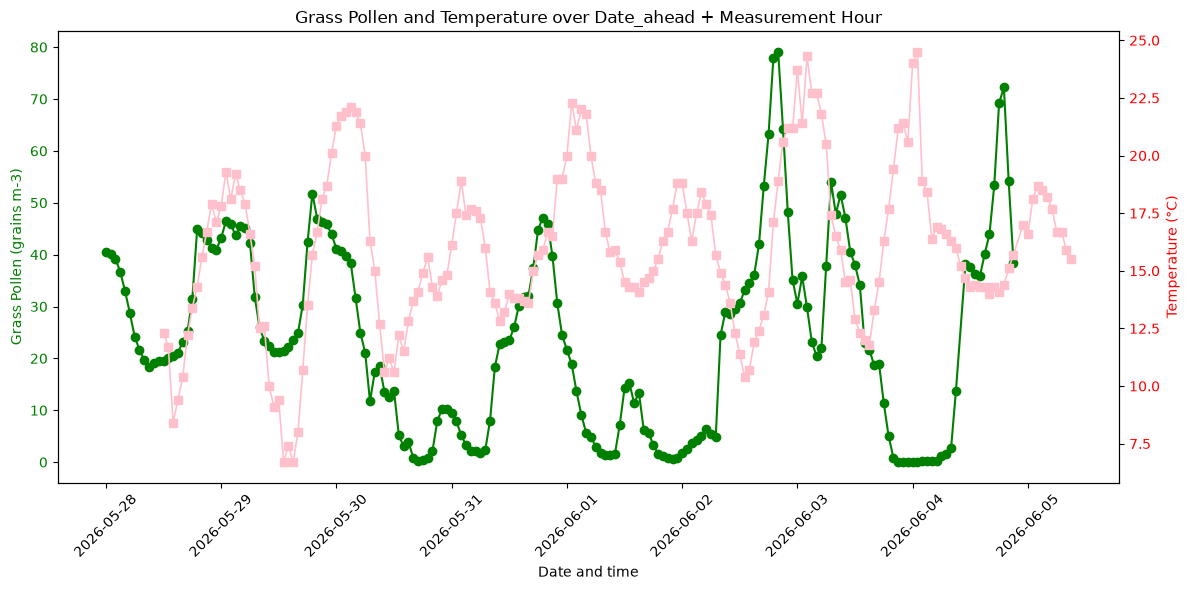

In [33]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)
x_ahead = plot_df_1['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [34]:
df_merged_from_date_range_2 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-07-02') & (df_merged_mean_temperature_by_date['date'] < '2026-07-09')].copy()
plot_df_2 = df_merged_from_date_range_2.sort_values(['date', 'measurement_hour'])
plot_df_2[50:100]

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
591,2026-07-04,2026-07-05 11:00:00,23:00:00,2026-07-04 23:00:00,12.200,2.000,220,71.700,0.100,1019.200,2026-07-05,11:00:00,45.742,15.800,night,12.850,3.000
562,2026-07-05,2026-07-05 12:00:00,00:00:00,2026-07-05 00:00:00,11.400,2.000,250,76.700,0.100,1019.000,2026-07-05,12:00:00,38.463,15.487,night,12.800,4.375
563,2026-07-05,2026-07-05 13:00:00,01:00:00,2026-07-05 01:00:00,11.200,2.000,250,82.700,0.100,1018.500,2026-07-05,13:00:00,35.792,15.487,night,12.800,4.375
564,2026-07-05,2026-07-05 14:00:00,02:00:00,2026-07-05 02:00:00,12.800,3.000,230,77.900,0.100,1017.900,2026-07-05,14:00:00,33.288,15.487,night,12.800,4.375
565,2026-07-05,2026-07-05 15:00:00,03:00:00,2026-07-05 03:00:00,13.200,3.000,230,79.600,0.100,1017.700,2026-07-05,15:00:00,26.512,15.487,night,12.800,4.375
566,2026-07-05,2026-07-05 16:00:00,04:00:00,2026-07-05 04:00:00,12.600,3.000,220,94.200,0.100,1017.300,2026-07-05,16:00:00,20.931,15.487,night,12.800,4.375
567,2026-07-05,2026-07-05 17:00:00,05:00:00,2026-07-05 05:00:00,13.200,3.000,210,94.200,0.100,1016.900,2026-07-05,17:00:00,18.963,15.487,day,16.594,4.375
568,2026-07-05,2026-07-05 18:00:00,06:00:00,2026-07-05 06:00:00,13.200,4.000,230,94.200,0.900,1016.600,2026-07-05,18:00:00,15.270,15.487,day,16.594,4.375
569,2026-07-05,2026-07-05 19:00:00,07:00:00,2026-07-05 07:00:00,13.600,4.000,220,96.100,0.900,1016.200,2026-07-05,19:00:00,14.845,15.487,day,16.594,4.375
570,2026-07-05,2026-07-05 20:00:00,08:00:00,2026-07-05 08:00:00,16.400,7.000,240,88.900,0.900,1015.600,2026-07-05,20:00:00,15.682,15.487,day,16.594,4.375


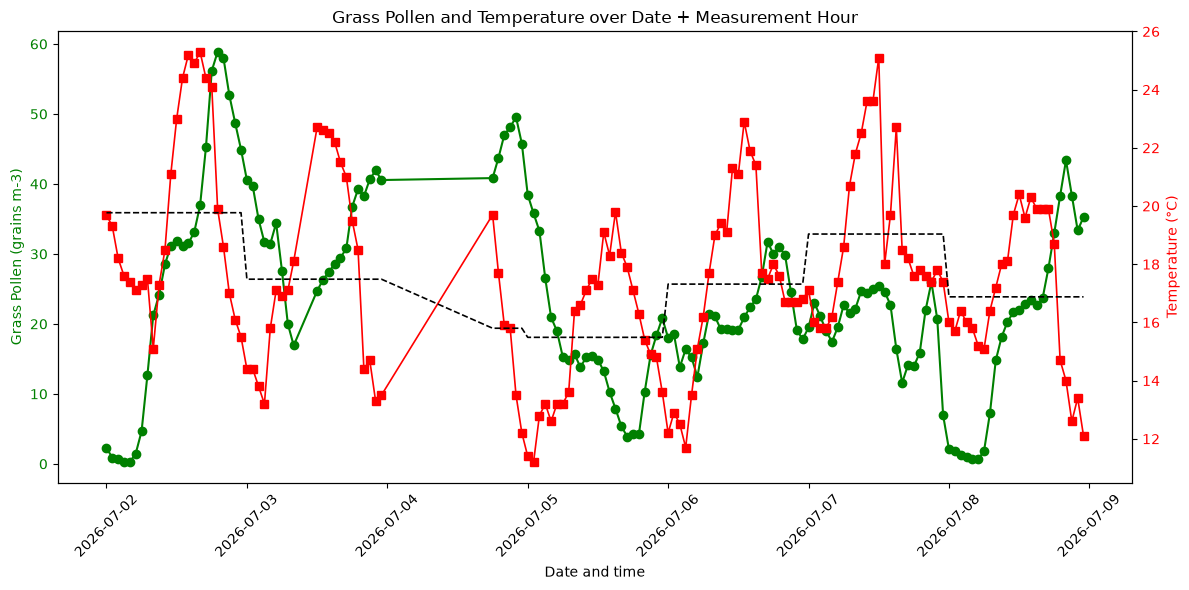

In [35]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
data_3 = plot_df_2['avg_day_temperature']

x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

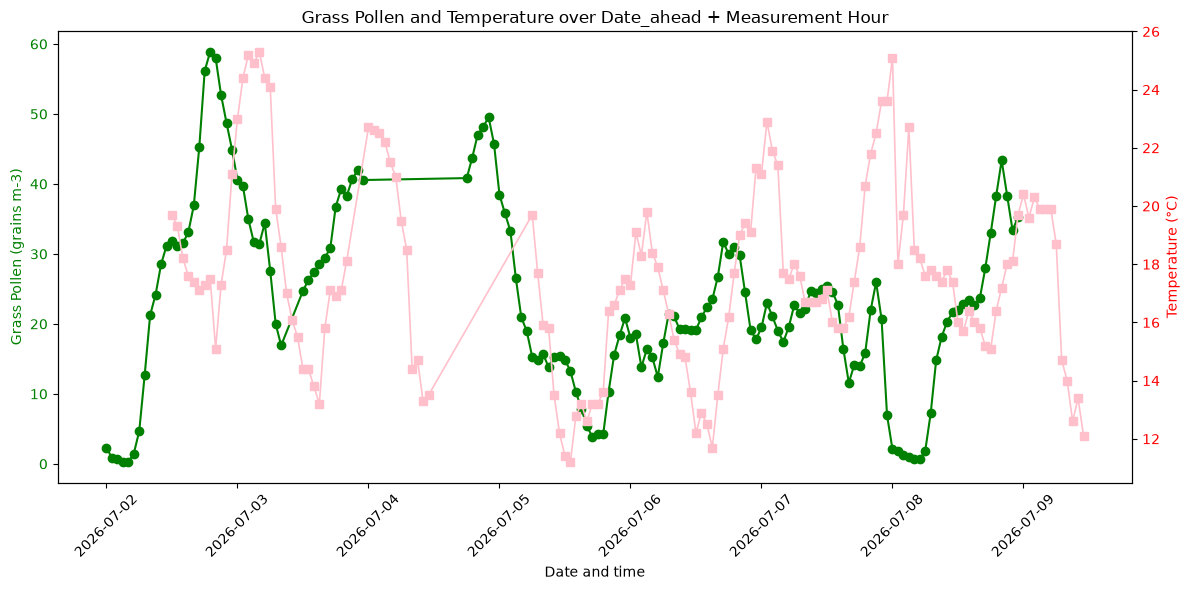

In [36]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

x_ahead = plot_df_2['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [37]:
df_merged_from_date_range_3 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-06-28') & (df_merged_mean_temperature_by_date['date'] < '2026-07-02')].copy()
plot_df_3 = df_merged_from_date_range_3.sort_values(['date', 'measurement_hour'])
plot_df_3[20:70]

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
729,2026-06-28,2026-06-29 08:00:00,20:00:00,2026-06-28 20:00:00,26.400,1.000,290,65.000,0.000,1017.800,2026-06-29,08:00:00,63.685,28.458,day,31.424,1.375
730,2026-06-28,2026-06-29 09:00:00,21:00:00,2026-06-28 21:00:00,25.800,0.000,0,68.300,0.000,1018.200,2026-06-29,09:00:00,65.491,28.458,day,31.424,1.375
731,2026-06-28,2026-06-29 10:00:00,22:00:00,2026-06-28 22:00:00,25.300,1.000,40,70.500,0.000,1018.400,2026-06-29,10:00:00,67.530,28.458,night,21.257,1.375
732,2026-06-28,2026-06-29 11:00:00,23:00:00,2026-06-28 23:00:00,23.700,0.000,0,78.300,0.000,1018.300,2026-06-29,11:00:00,71.064,28.458,night,21.257,1.375
685,2026-06-29,2026-06-29 12:00:00,00:00:00,2026-06-29 00:00:00,22.700,0.000,0,83.800,0.000,1018.200,2026-06-29,12:00:00,66.219,28.904,night,22.043,2.292
686,2026-06-29,2026-06-29 13:00:00,01:00:00,2026-06-29 01:00:00,21.400,1.000,20,87.500,0.000,1018.200,2026-06-29,13:00:00,63.154,28.904,night,22.043,2.292
687,2026-06-29,2026-06-29 14:00:00,02:00:00,2026-06-29 02:00:00,20.800,0.000,0,88.600,0.000,1018.200,2026-06-29,14:00:00,62.713,28.904,night,22.043,2.292
688,2026-06-29,2026-06-29 15:00:00,03:00:00,2026-06-29 03:00:00,20.600,0.000,0,88.600,0.000,1018.300,2026-06-29,15:00:00,58.815,28.904,night,22.043,2.292
689,2026-06-29,2026-06-29 16:00:00,04:00:00,2026-06-29 04:00:00,22.200,1.000,270,79.600,0.000,1018.300,2026-06-29,16:00:00,56.225,28.904,night,22.043,2.292
690,2026-06-29,2026-06-29 17:00:00,05:00:00,2026-06-29 05:00:00,26.800,0.000,0,59.900,0.000,1017.900,2026-06-29,17:00:00,50.333,28.904,day,31.729,2.292


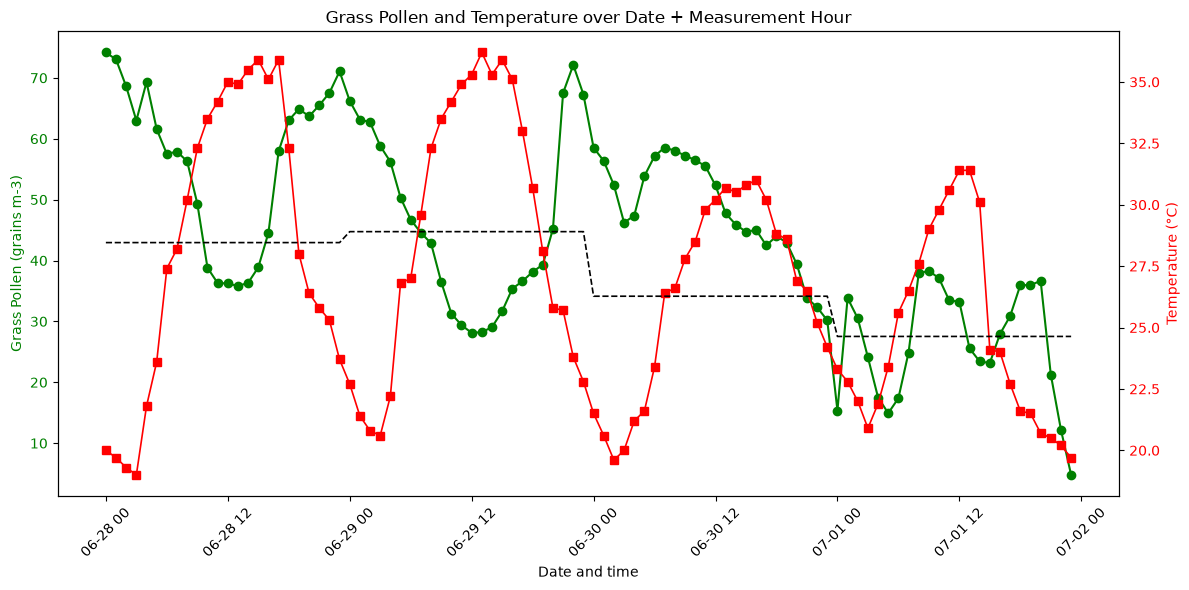

In [38]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
data_3 = plot_df_3['avg_day_temperature']

x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

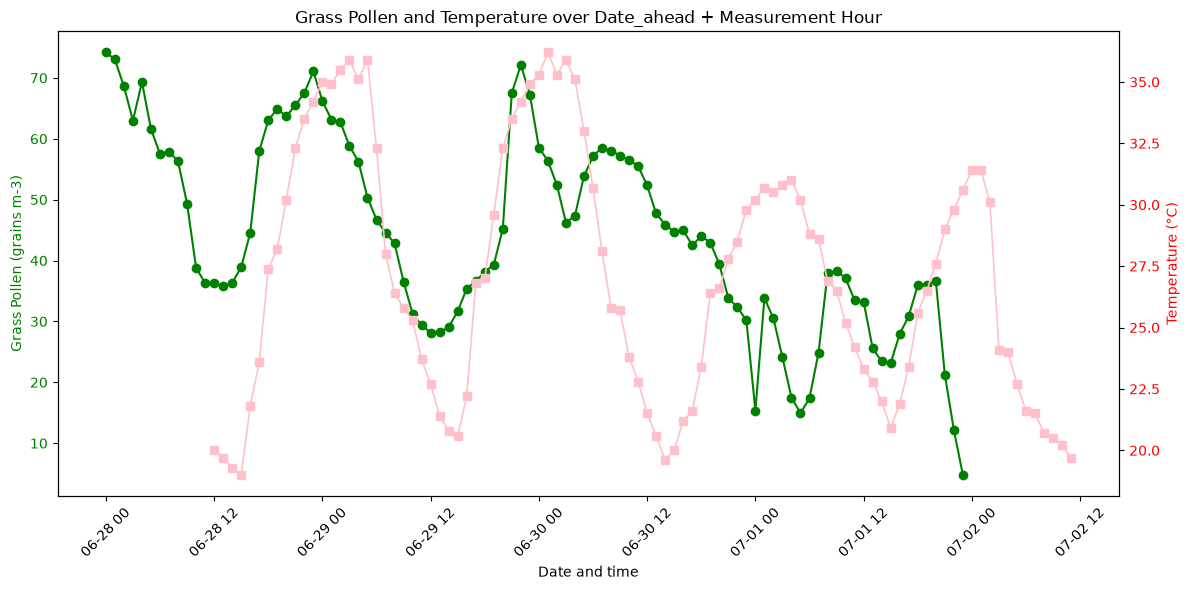

In [39]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [40]:
df_merged_from_date_range_June = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-06-01') & (df_merged_mean_temperature_by_date['date'] < '2026-06-30')].copy()
plot_df_June = df_merged_from_date_range_June.sort_values(['date', 'measurement_hour'])
plot_df_June[470:520]

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
919,2026-06-20,2026-06-21 06:00:00,18:00:00,2026-06-20 18:00:00,25.700,2.000,30,67.000,2.300,1020.700,2026-06-21,06:00:00,61.432,22.829,day,23.941,2.542
920,2026-06-20,2026-06-21 07:00:00,19:00:00,2026-06-20 19:00:00,24.800,3.000,40,69.500,2.300,1021.000,2026-06-21,07:00:00,70.739,22.829,day,23.941,2.542
921,2026-06-20,2026-06-21 08:00:00,20:00:00,2026-06-20 20:00:00,22.600,3.000,30,77.600,2.300,1021.700,2026-06-21,08:00:00,57.867,22.829,day,23.941,2.542
922,2026-06-20,2026-06-21 09:00:00,21:00:00,2026-06-20 21:00:00,22.800,3.000,20,73.300,2.300,1021.700,2026-06-21,09:00:00,41.372,22.829,day,23.941,2.542
923,2026-06-20,2026-06-21 10:00:00,22:00:00,2026-06-20 22:00:00,21.900,4.000,270,76.600,2.300,1022.600,2026-06-21,10:00:00,27.896,22.829,night,20.129,2.542
924,2026-06-20,2026-06-21 11:00:00,23:00:00,2026-06-20 23:00:00,21.200,2.000,20,80.500,2.300,1022.600,2026-06-21,11:00:00,25.125,22.829,night,20.129,2.542
877,2026-06-21,2026-06-21 12:00:00,00:00:00,2026-06-21 00:00:00,20.100,3.000,240,86.900,2.300,1022.500,2026-06-21,12:00:00,22.776,22.004,night,19.357,2.167
878,2026-06-21,2026-06-21 13:00:00,01:00:00,2026-06-21 01:00:00,18.400,2.000,250,92.000,2.300,1022.700,2026-06-21,13:00:00,18.381,22.004,night,19.357,2.167
879,2026-06-21,2026-06-21 14:00:00,02:00:00,2026-06-21 02:00:00,19.000,1.000,230,93.800,2.300,1022.800,2026-06-21,14:00:00,15.024,22.004,night,19.357,2.167
880,2026-06-21,2026-06-21 15:00:00,03:00:00,2026-06-21 03:00:00,18.900,1.000,220,92.000,2.300,1023.200,2026-06-21,15:00:00,13.319,22.004,night,19.357,2.167


In [41]:
plot_df_June[520:570]

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
873,2026-06-22,2026-06-23 08:00:00,20:00:00,2026-06-22 20:00:00,18.700,2.000,230,95.600,1.500,1022.500,2026-06-23,08:00:00,5.132,20.033,day,20.924,2.458
874,2026-06-22,2026-06-23 09:00:00,21:00:00,2026-06-22 21:00:00,18.100,0.000,0,98.100,1.500,1022.300,2026-06-23,09:00:00,16.081,20.033,day,20.924,2.458
875,2026-06-22,2026-06-23 10:00:00,22:00:00,2026-06-22 22:00:00,17.300,1.000,220,98.700,1.500,1022.200,2026-06-23,10:00:00,31.107,20.033,night,17.871,2.458
876,2026-06-22,2026-06-23 11:00:00,23:00:00,2026-06-22 23:00:00,17.100,2.000,250,98.100,1.500,1022.200,2026-06-23,11:00:00,46.660,20.033,night,17.871,2.458
829,2026-06-23,2026-06-23 12:00:00,00:00:00,2026-06-23 00:00:00,16.300,1.000,250,98.100,1.500,1021.900,2026-06-23,12:00:00,60.509,21.425,night,16.286,1.667
830,2026-06-23,2026-06-23 13:00:00,01:00:00,2026-06-23 01:00:00,15.100,2.000,240,98.700,1.500,1021.700,2026-06-23,13:00:00,69.391,21.425,night,16.286,1.667
831,2026-06-23,2026-06-23 14:00:00,02:00:00,2026-06-23 02:00:00,14.900,1.000,170,98.700,1.500,1021.700,2026-06-23,14:00:00,76.283,21.425,night,16.286,1.667
832,2026-06-23,2026-06-23 15:00:00,03:00:00,2026-06-23 03:00:00,14.300,0.000,0,98.700,1.500,1022.100,2026-06-23,15:00:00,68.375,21.425,night,16.286,1.667
833,2026-06-23,2026-06-23 16:00:00,04:00:00,2026-06-23 04:00:00,15.400,0.000,0,91.800,1.500,1022.100,2026-06-23,16:00:00,60.945,21.425,night,16.286,1.667
834,2026-06-23,2026-06-23 17:00:00,05:00:00,2026-06-23 05:00:00,17.000,1.000,230,82.700,1.500,1021.900,2026-06-23,17:00:00,53.740,21.425,day,23.541,1.667


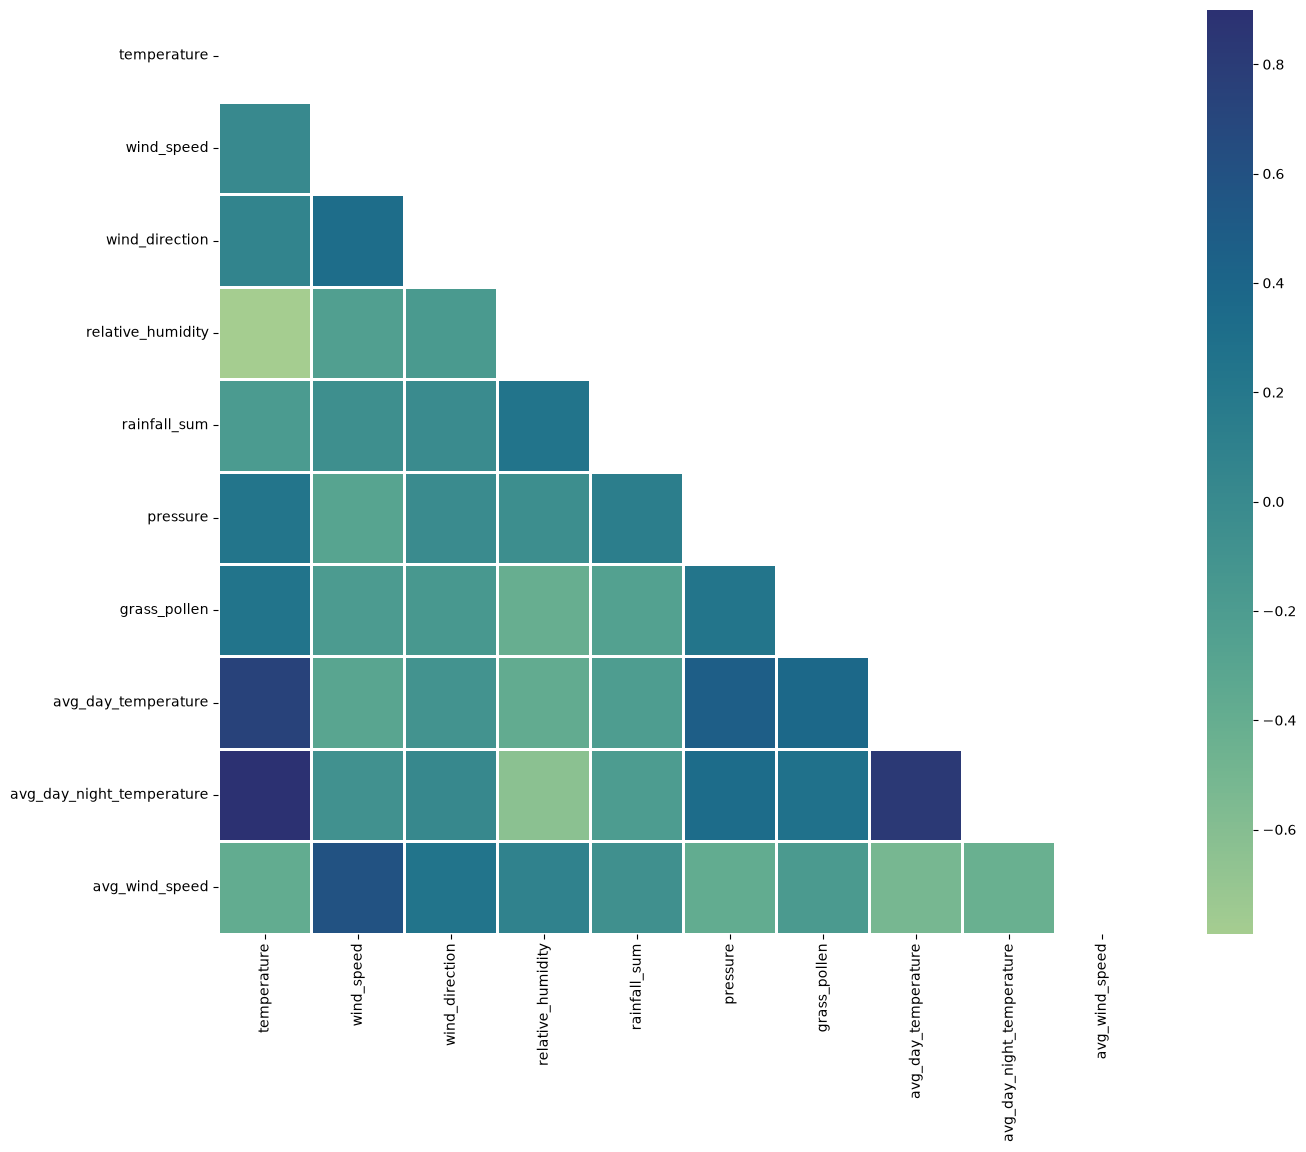

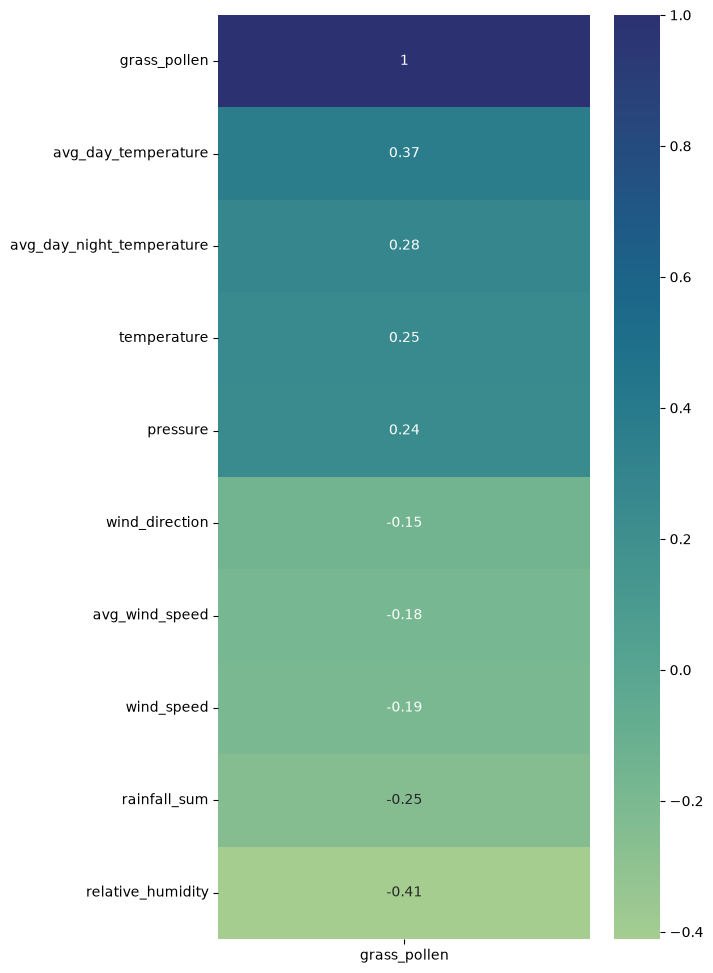

In [42]:
#corr June 2026
#triangular matrix
num_cols_day_night_temperature = plot_df_June.select_dtypes(['int', 'float']).columns
corr_data_day_night_temperature = plot_df_June[num_cols_day_night_temperature]

corr_coef_day_night_temperature = corr_data_day_night_temperature.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef_day_night_temperature)
sns.heatmap(corr_coef_day_night_temperature,linewidth=.8, mask = matrix, cmap="crest")

plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_day_night_temperature[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);

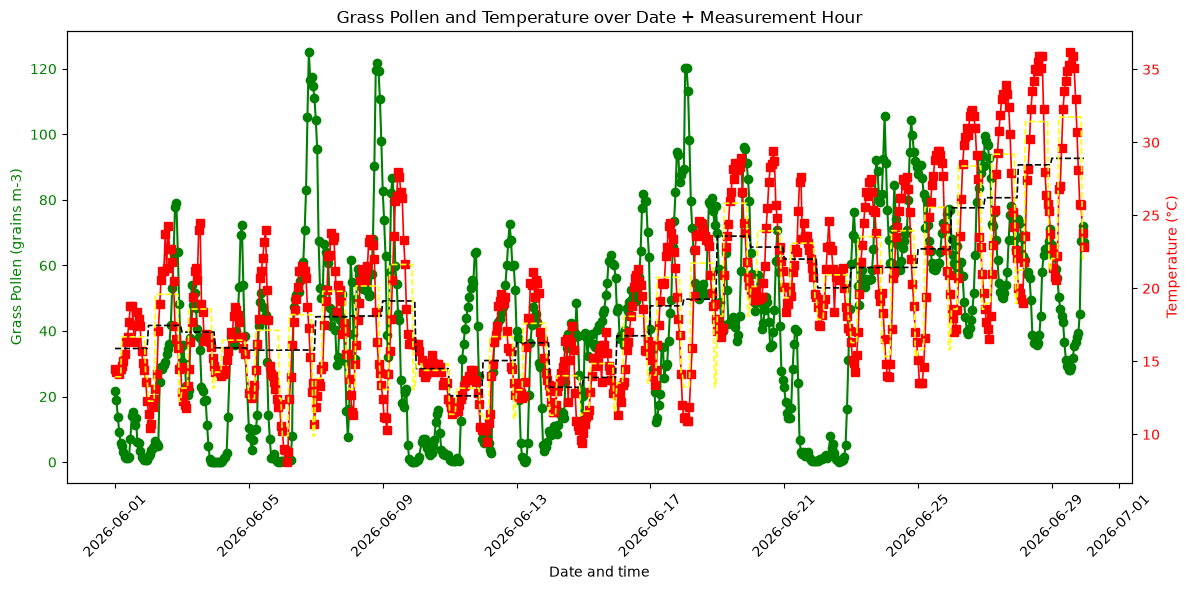

In [43]:
data_1 = plot_df_June['grass_pollen']
data_2 = plot_df_June['temperature']
data_3 = plot_df_June['avg_day_temperature']
data_4 = plot_df_June['avg_day_night_temperature']

x = pd.to_datetime(
    plot_df_June['date'].astype(str)
    + ' '    
    + plot_df_June['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.plot(x, data_4, color='yellow', linewidth=1.2, linestyle='--', label='Avg Day Night Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

In [44]:
#rainfall vs grass pollen 20.06.2026 - 25.06.2026
df_merged_from_date_range_rainfall = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-06-20') & (df_merged_mean_temperature_by_date['date'] < '2026-06-25')].copy()
plot_df_rainfall = df_merged_from_date_range_rainfall.sort_values(['date', 'measurement_hour'])
plot_df_rainfall[0:50] 

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
901,2026-06-20,2026-06-20 12:00:00,00:00:00,2026-06-20 00:00:00,19.900,2.000,30,84.700,0.000,1020.300,2026-06-20,12:00:00,63.915,22.829,night,20.129,2.542
902,2026-06-20,2026-06-20 13:00:00,01:00:00,2026-06-20 01:00:00,19.600,3.000,20,84.600,0.000,1020.300,2026-06-20,13:00:00,57.478,22.829,night,20.129,2.542
903,2026-06-20,2026-06-20 14:00:00,02:00:00,2026-06-20 02:00:00,19.200,3.000,30,86.800,0.000,1020.400,2026-06-20,14:00:00,48.829,22.829,night,20.129,2.542
904,2026-06-20,2026-06-20 15:00:00,03:00:00,2026-06-20 03:00:00,19.200,2.000,20,86.800,0.000,1020.500,2026-06-20,15:00:00,46.159,22.829,night,20.129,2.542
905,2026-06-20,2026-06-20 16:00:00,04:00:00,2026-06-20 04:00:00,19.900,2.000,30,82.500,0.000,1021.100,2026-06-20,16:00:00,48.827,22.829,night,20.129,2.542
906,2026-06-20,2026-06-20 17:00:00,05:00:00,2026-06-20 05:00:00,19.300,1.000,190,92.600,0.000,1021.700,2026-06-20,17:00:00,57.047,22.829,day,23.941,2.542
907,2026-06-20,2026-06-20 18:00:00,06:00:00,2026-06-20 06:00:00,19.300,3.000,200,95.600,2.300,1021.800,2026-06-20,18:00:00,49.027,22.829,day,23.941,2.542
908,2026-06-20,2026-06-20 19:00:00,07:00:00,2026-06-20 07:00:00,19.400,1.000,10,93.800,2.300,1022.600,2026-06-20,19:00:00,48.630,22.829,day,23.941,2.542
909,2026-06-20,2026-06-20 20:00:00,08:00:00,2026-06-20 08:00:00,19.400,4.000,30,93.800,2.300,1023.200,2026-06-20,20:00:00,40.456,22.829,day,23.941,2.542
910,2026-06-20,2026-06-20 21:00:00,09:00:00,2026-06-20 09:00:00,20.400,3.000,140,87.500,2.300,1022.700,2026-06-20,21:00:00,42.383,22.829,day,23.941,2.542


In [45]:
plot_df_rainfall.tail(50)

,date,date_N_h_ahead,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature,day_night,avg_day_night_temperature,avg_wind_speed
875,2026-06-22,2026-06-23 10:00:00,22:00:00,2026-06-22 22:00:00,17.300,1.000,220,98.700,1.500,1022.200,2026-06-23,10:00:00,31.107,20.033,night,17.871,2.458
876,2026-06-22,2026-06-23 11:00:00,23:00:00,2026-06-22 23:00:00,17.100,2.000,250,98.100,1.500,1022.200,2026-06-23,11:00:00,46.660,20.033,night,17.871,2.458
829,2026-06-23,2026-06-23 12:00:00,00:00:00,2026-06-23 00:00:00,16.300,1.000,250,98.100,1.500,1021.900,2026-06-23,12:00:00,60.509,21.425,night,16.286,1.667
830,2026-06-23,2026-06-23 13:00:00,01:00:00,2026-06-23 01:00:00,15.100,2.000,240,98.700,1.500,1021.700,2026-06-23,13:00:00,69.391,21.425,night,16.286,1.667
831,2026-06-23,2026-06-23 14:00:00,02:00:00,2026-06-23 02:00:00,14.900,1.000,170,98.700,1.500,1021.700,2026-06-23,14:00:00,76.283,21.425,night,16.286,1.667
832,2026-06-23,2026-06-23 15:00:00,03:00:00,2026-06-23 03:00:00,14.300,0.000,0,98.700,1.500,1022.100,2026-06-23,15:00:00,68.375,21.425,night,16.286,1.667
833,2026-06-23,2026-06-23 16:00:00,04:00:00,2026-06-23 04:00:00,15.400,0.000,0,91.800,1.500,1022.100,2026-06-23,16:00:00,60.945,21.425,night,16.286,1.667
834,2026-06-23,2026-06-23 17:00:00,05:00:00,2026-06-23 05:00:00,17.000,1.000,230,82.700,1.500,1021.900,2026-06-23,17:00:00,53.740,21.425,day,23.541,1.667
835,2026-06-23,2026-06-23 18:00:00,06:00:00,2026-06-23 06:00:00,19.600,2.000,210,74.300,20.800,1021.800,2026-06-23,18:00:00,48.009,21.425,day,23.541,1.667
836,2026-06-23,2026-06-23 19:00:00,07:00:00,2026-06-23 07:00:00,21.800,2.000,220,63.400,20.800,1021.500,2026-06-23,19:00:00,56.509,21.425,day,23.541,1.667


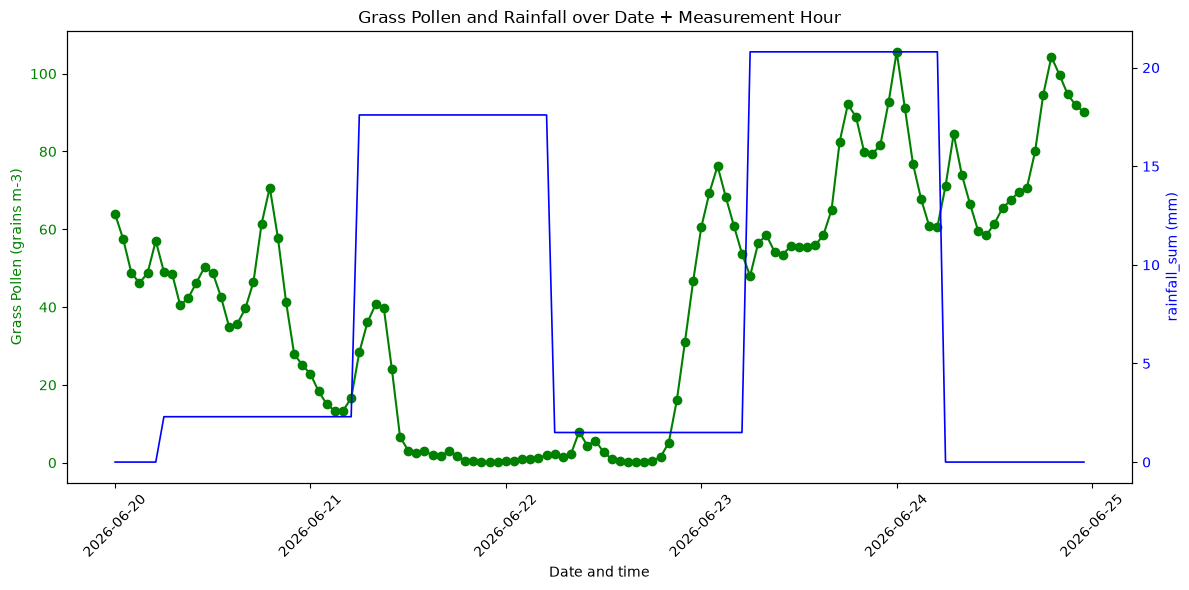

In [46]:
data_1 = plot_df_rainfall['grass_pollen']
data_2 = plot_df_rainfall['rainfall_sum']


x = pd.to_datetime(
    plot_df_rainfall['date'].astype(str)
    + ' '    
    + plot_df_rainfall['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('rainfall_sum (mm)', color='blue')
ax2.plot(x, data_2, color='blue', linewidth=1.2)

ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Grass Pollen and Rainfall over Date + Measurement Hour')
plt.tight_layout()
plt.show()

<Axes: >

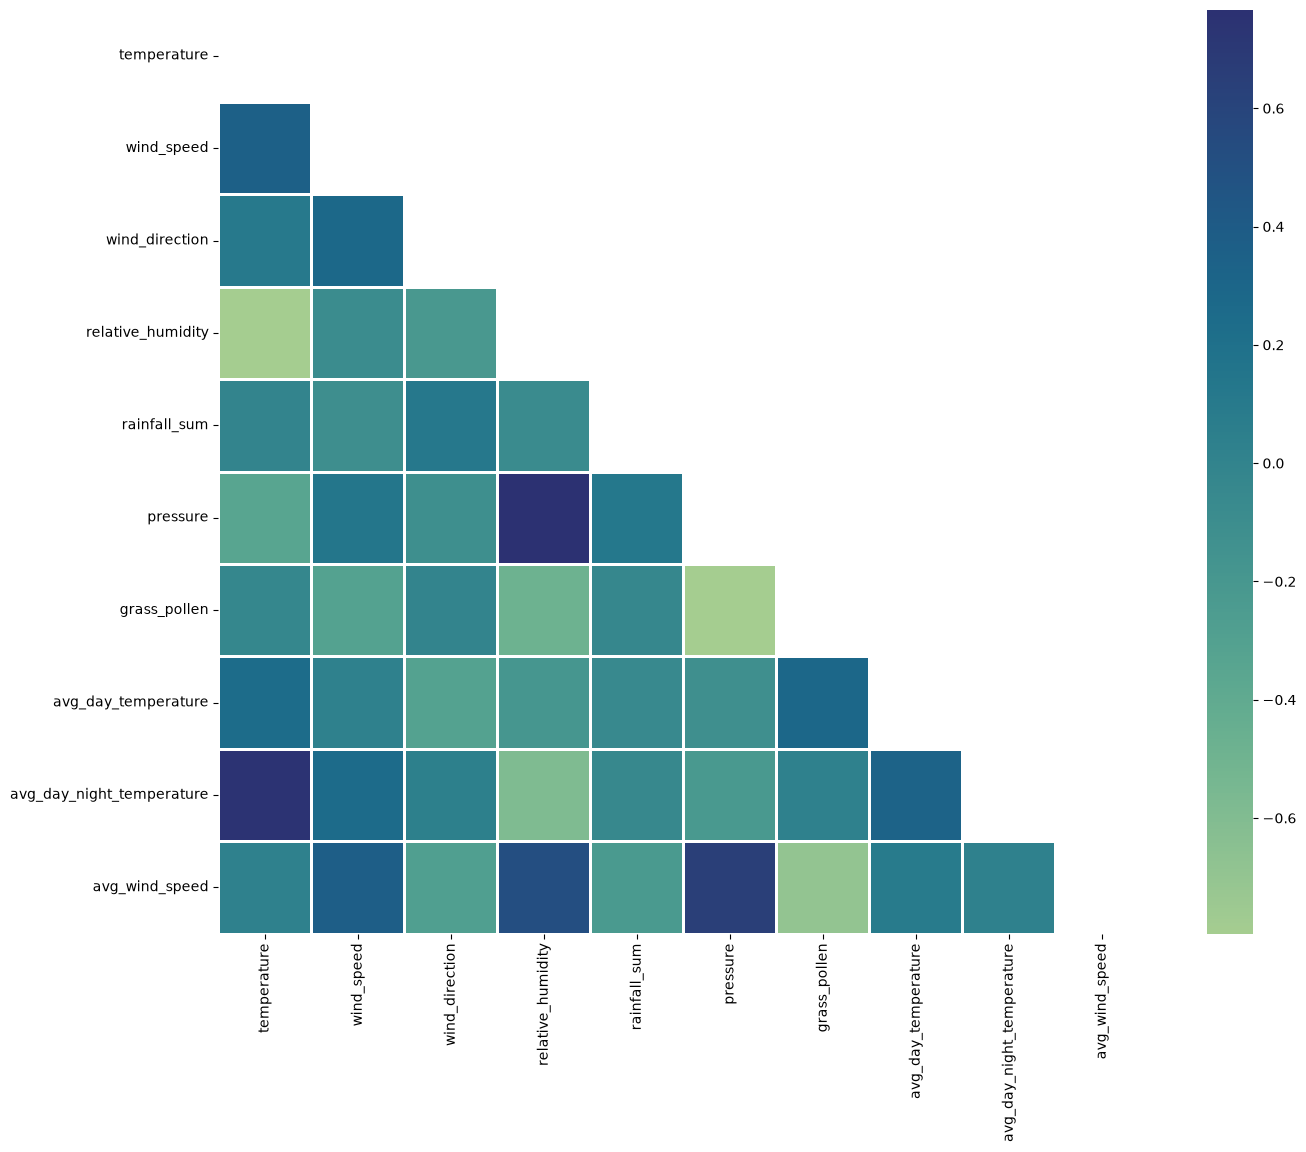

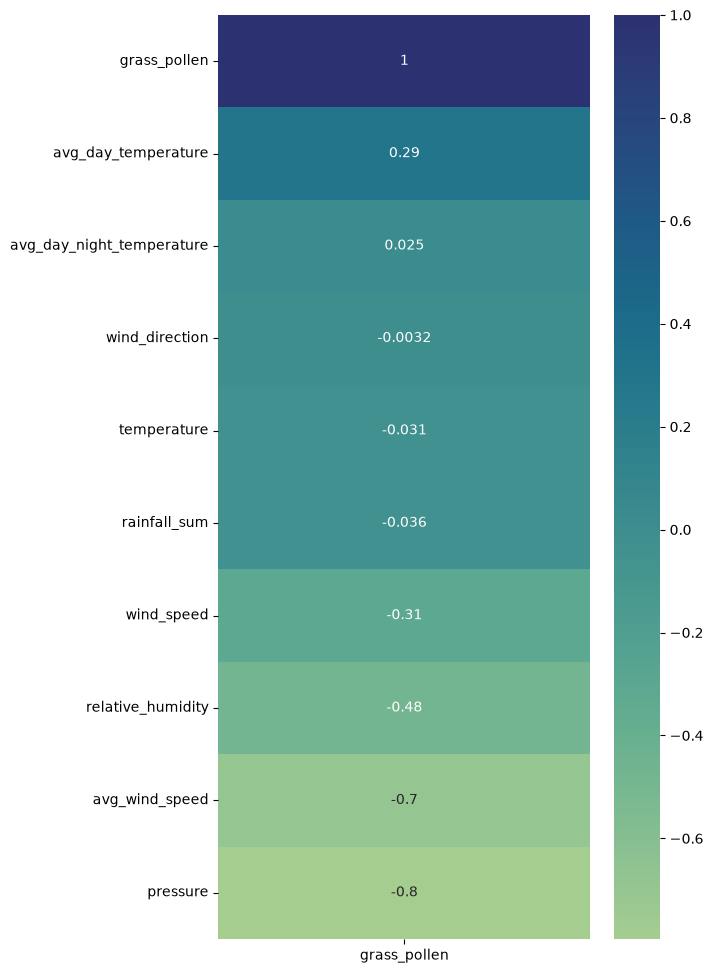

In [47]:
#corr rainfall vs grass pollen 20.06.2026 - 25.06.2026
#triangular matrix
num_cols_rainfall = plot_df_rainfall.select_dtypes(['int', 'float']).columns
corr_data_rainfall = plot_df_rainfall[num_cols_rainfall]

corr_coef_rainfall = corr_data_rainfall.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef_rainfall)
sns.heatmap(corr_coef_rainfall,linewidth=.8, mask = matrix, cmap="crest")

plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_rainfall[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True)

<Axes: >

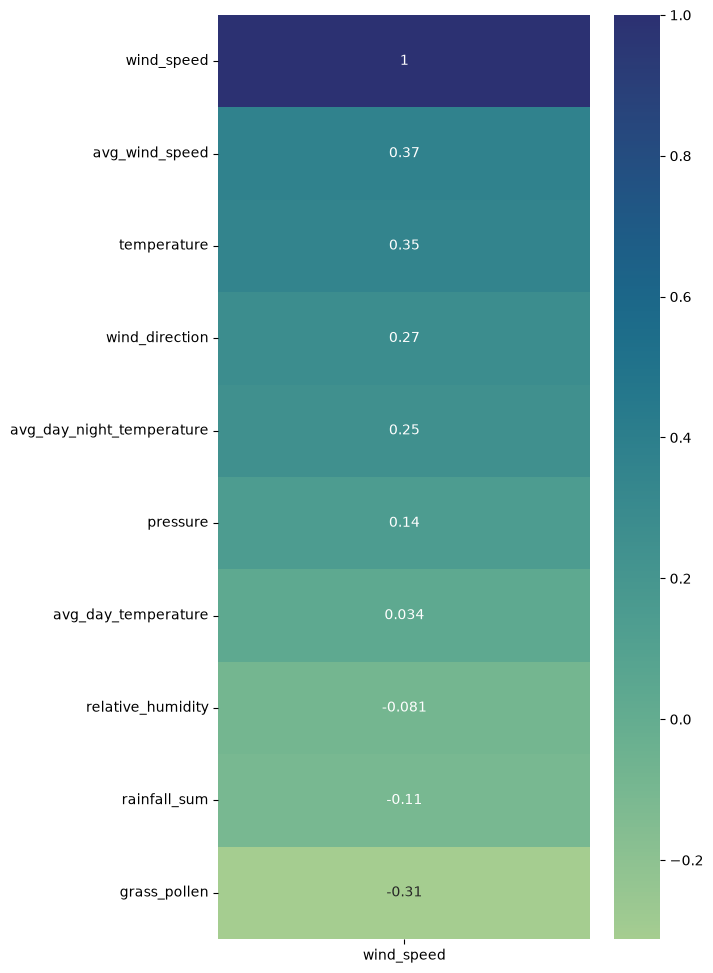

In [48]:
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_rainfall[['wind_speed']].sort_values(by=['wind_speed'], ascending=False),
            cmap='crest',
            annot=True)

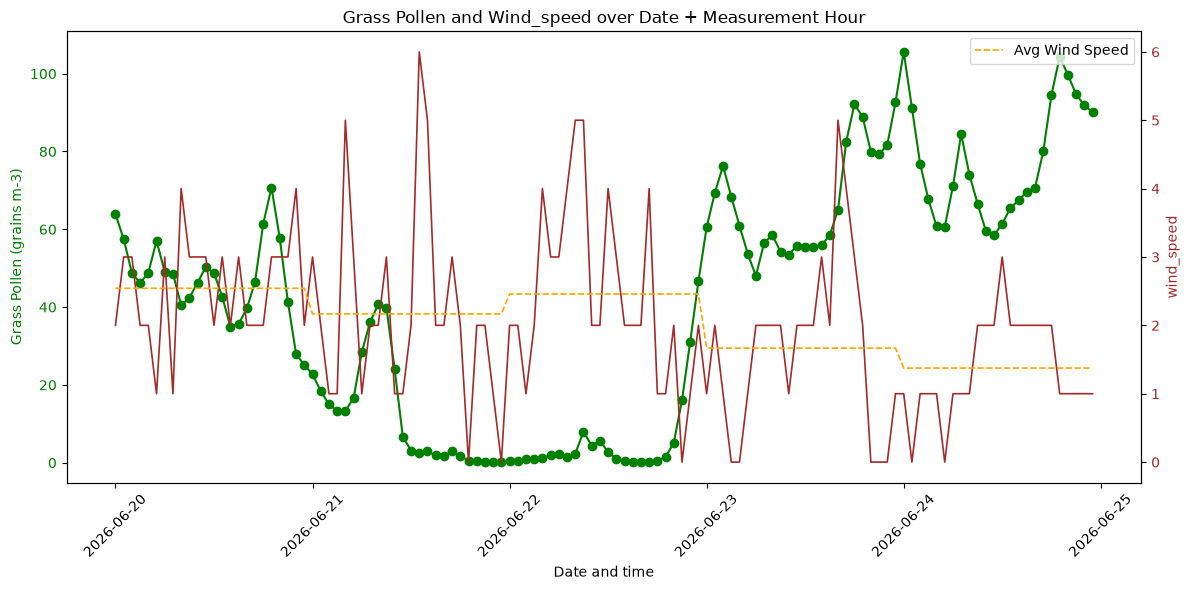

In [49]:
#wind_speed vs grass pollen 20.06.2026 - 25.06.2026
data_1 = plot_df_rainfall['grass_pollen']
data_2 = plot_df_rainfall['wind_speed']
data_3 = plot_df_rainfall['avg_wind_speed']

x = pd.to_datetime(
    plot_df_rainfall['date'].astype(str)
    + ' '    
    + plot_df_rainfall['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('wind_speed', color='brown')
ax2.plot(x, data_2, color='brown', linewidth=1.2)
ax2.plot(x, data_3, color='orange', linewidth=1.2, linestyle='--', label='Avg Wind Speed')

ax2.tick_params(axis='y', labelcolor='brown')

plt.title('Grass Pollen and Wind_speed over Date + Measurement Hour')
plt.legend()
plt.tight_layout()
plt.show()

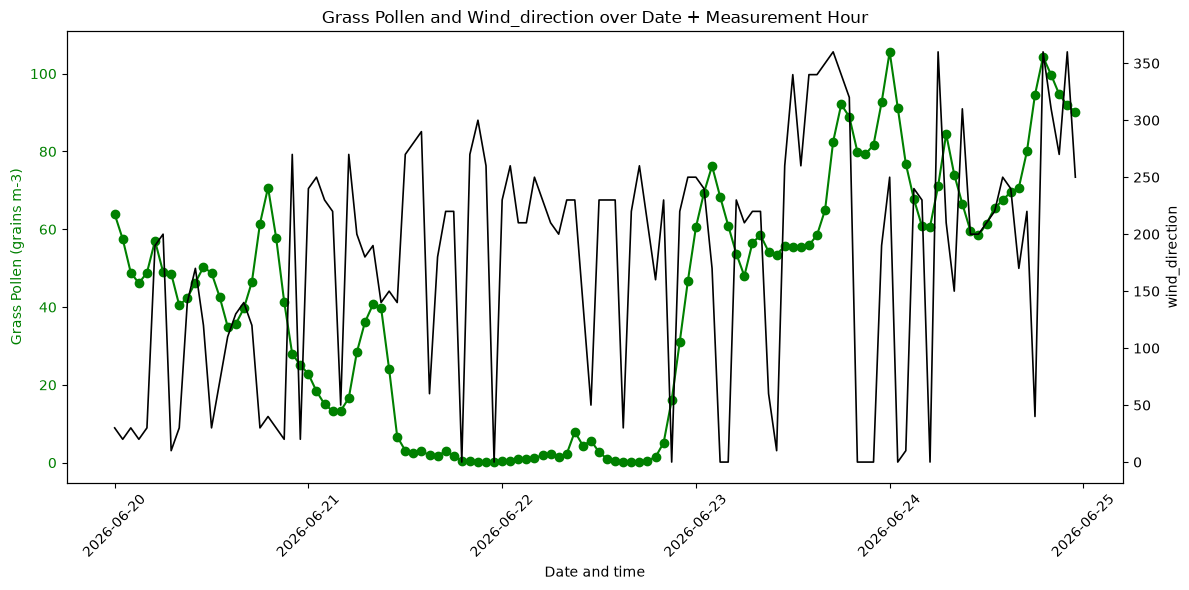

In [50]:
#wind_direction vs grass pollen 20.06.2026 - 25.06.2026
data_1 = plot_df_rainfall['grass_pollen']
data_2 = plot_df_rainfall['wind_direction']

x = pd.to_datetime(
    plot_df_rainfall['date'].astype(str)
    + ' '    
    + plot_df_rainfall['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('wind_direction', color='black')
ax2.plot(x, data_2, color='black', linewidth=1.2)

ax2.tick_params(axis='y', labelcolor='black')

plt.title('Grass Pollen and Wind_direction over Date + Measurement Hour')
plt.tight_layout()
plt.show()

In [51]:
# Prepare predictor matrix and target variable all cols
feature_cols_all = [col for col in ['wind_speed', 'rainfall_sum', 'wind_direction', 'temperature', 'relative_humidity', 'pressure'] if col in plot_df_rainfall.columns]

X_all = plot_df_rainfall[feature_cols_all].copy()
y = plot_df_rainfall['grass_pollen']

X_all.head()

,wind_speed,rainfall_sum,wind_direction,temperature,relative_humidity,pressure
901,2.000,0.000,30,19.900,84.700,1020.300
902,3.000,0.000,20,19.600,84.600,1020.300
903,3.000,0.000,30,19.200,86.800,1020.400
904,2.000,0.000,20,19.200,86.800,1020.500
905,2.000,0.000,30,19.900,82.500,1021.100


In [52]:
scaler_6f = StandardScaler()
scaler_6f.fit(X_all)
pca_data_scaled_6f = scaler_6f.transform(X_all)

In [53]:
pca = PCA(n_components=6)
pca.fit(pca_data_scaled_6f)
pca_wind_rain_6f = pca.transform(pca_data_scaled_6f)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_all,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
loadings


,PC1,PC2,PC3,PC4,PC5,PC6
wind_speed,-0.170,0.740,-0.269,-0.177,0.563,-0.057
rainfall_sum,0.009,0.054,0.888,-0.369,0.250,0.098
wind_direction,-0.215,0.470,0.348,0.727,-0.281,0.063
temperature,-0.543,0.148,-0.101,-0.442,-0.496,0.482
relative_humidity,0.627,0.157,-0.081,0.074,0.043,0.754
pressure,0.486,0.427,0.035,-0.321,-0.542,-0.427


In [54]:
eigenvalues = pca.explained_variance_
prop_var = eigenvalues / np.sum(eigenvalues)

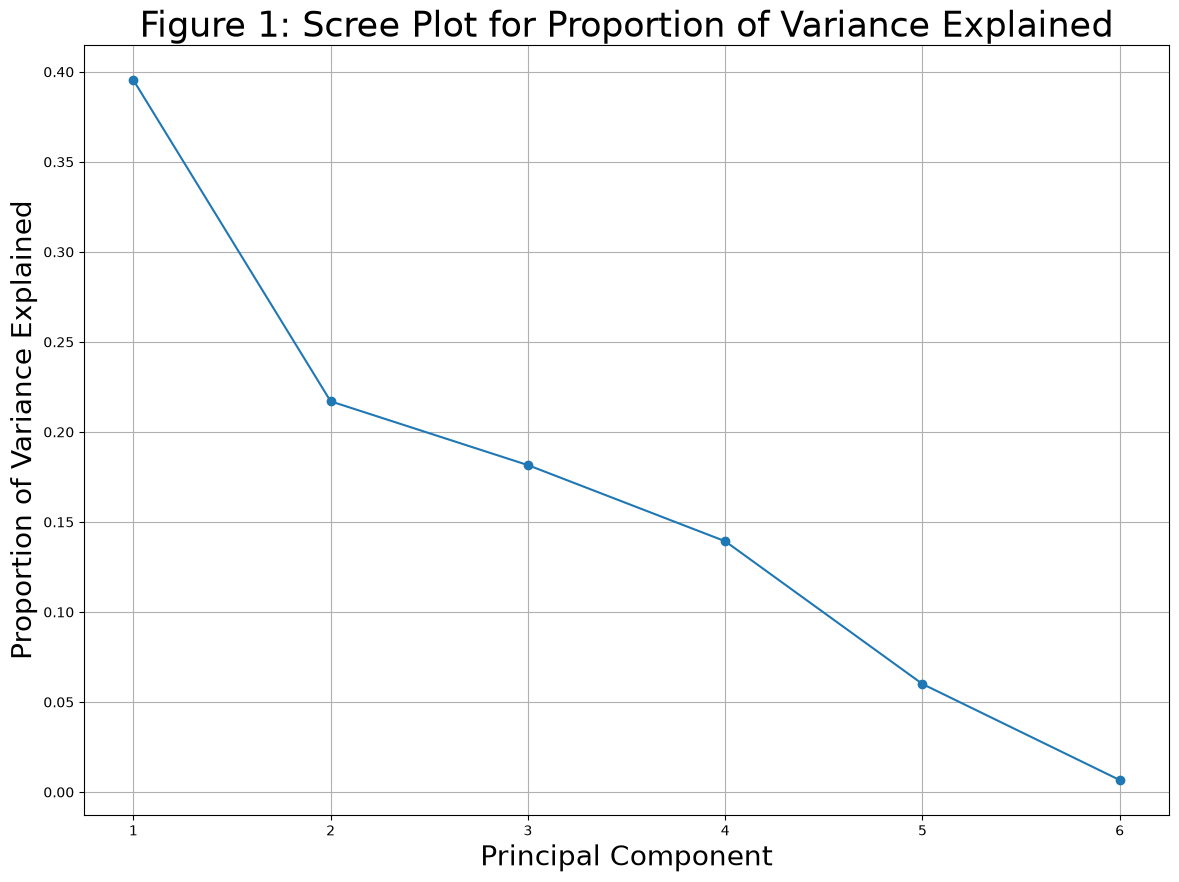

In [55]:
plt.figure(figsize=(14,10))
plt.plot(np.arange(1, len(prop_var)+1), 
                   prop_var, marker='o')
plt.xlabel('Principal Component',
           size = 20)
plt.ylabel('Proportion of Variance Explained',
           size = 20)
plt.title('Figure 1: Scree Plot for Proportion of Variance Explained',
          size = 25)
plt.grid(True)

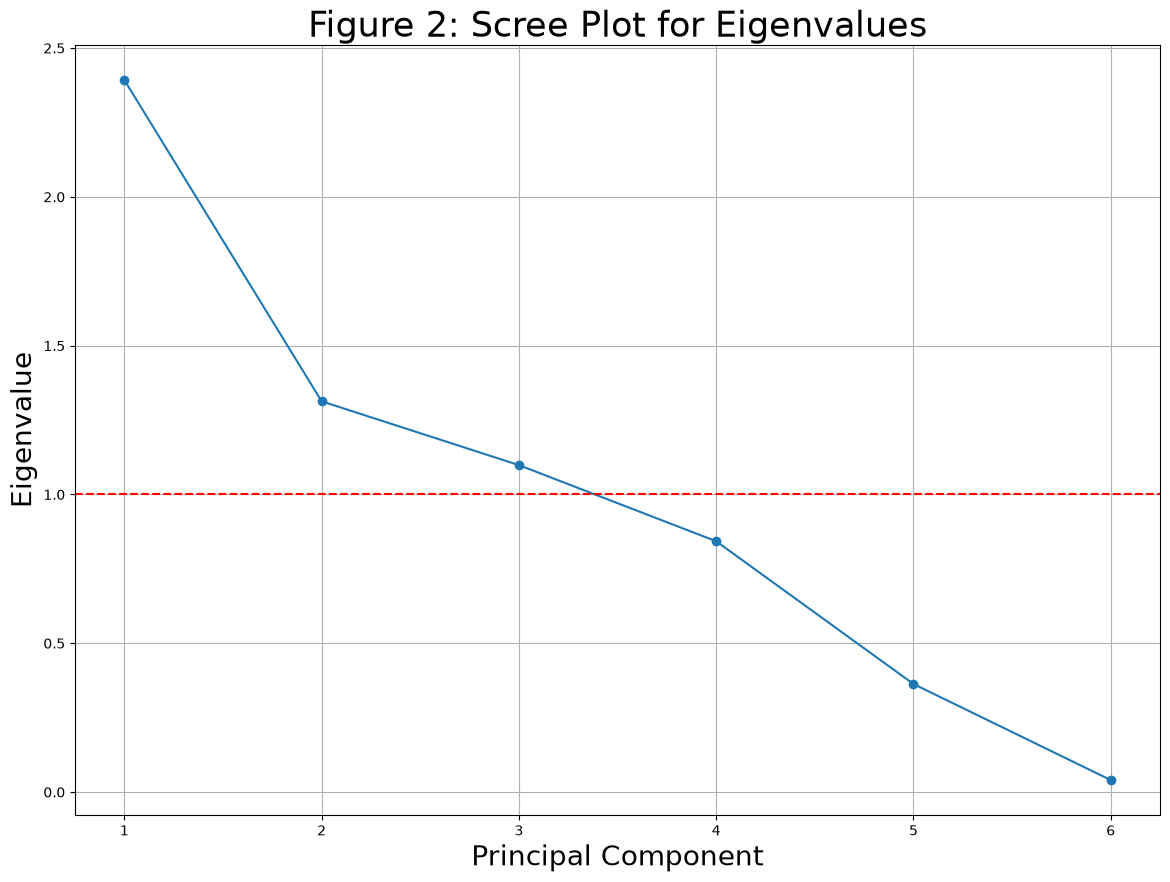

In [56]:
plt.figure(figsize=(14,10))
plt.plot(np.arange(1, len(eigenvalues)+1), 
         eigenvalues, marker='o')
plt.xlabel('Principal Component',
           size = 20)
plt.ylabel('Eigenvalue',
           size = 20)
plt.title('Figure 2: Scree Plot for Eigenvalues',
          size = 25)
plt.axhline(y=1, color='r', 
            linestyle='--')
plt.grid(True)

Principal component analysis was performed on the standardized predictor matrix. The first three principal components were retained because their eigenvalues were greater than 1 and they captured the largest proportion of explained variance, as shown by the scree plot.


In [57]:
pca = PCA(n_components=3)
pca.fit(pca_data_scaled_6f)
pca_wind_rain_6f = pca.transform(pca_data_scaled_6f)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_all,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
loadings

,PC1,PC2,PC3
wind_speed,-0.170,0.740,-0.269
rainfall_sum,0.009,0.054,0.888
wind_direction,-0.215,0.470,0.348
temperature,-0.543,0.148,-0.101
relative_humidity,0.627,0.157,-0.081
pressure,0.486,0.427,0.035


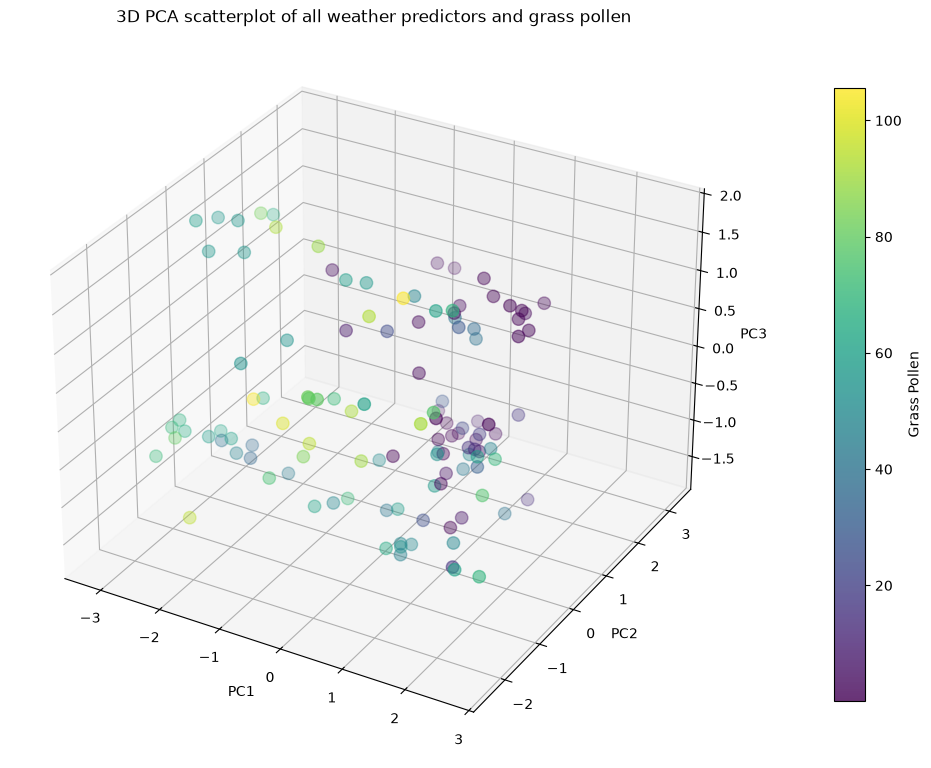

In [58]:
# 3D Scatterplot
Xax = pca_wind_rain_6f[:,0]
Yax = pca_wind_rain_6f[:,1]
Zax = pca_wind_rain_6f[:,2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    Xax,
    Yax,
    Zax,
    c=y,
    cmap='viridis',
    s=80,
    alpha=0.8
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA scatterplot of all weather predictors and grass pollen')
fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8).set_label('Grass Pollen')
plt.tight_layout()
plt.show()

In [32]:
engine_render = create_engine(get_database_render_url(), pool_pre_ping=True)
df_synop_raw = pd.read_sql(
    """SELECT * FROM public.synop_data
    ORDER BY date DESC, measurement_hour ASC """,
    engine_render
)

df_synop_raw.head()



,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,12566,2026-08-03,0,2026-08-03 01:00:47.212255,2026-08-03 01:00:47.210109,Kraków,19.700,3.000,30,85.700,4.600,1019.100
1,12566,2026-08-03,1,2026-08-03 02:00:20.968925,2026-08-03 02:00:20.966848,Kraków,19.300,4.000,40,84.600,4.600,1018.600
2,12566,2026-08-03,2,2026-08-03 03:00:27.041495,2026-08-03 03:00:27.033311,Kraków,18.800,4.000,40,84.600,4.600,1018.400
3,12566,2026-08-03,3,2026-08-03 04:00:47.276842,2026-08-03 04:00:47.274152,Kraków,18.500,4.000,50,85.600,4.600,1018.400
4,12566,2026-08-03,4,2026-08-03 05:00:58.484122,2026-08-03 05:00:58.481559,Kraków,18.500,5.000,40,85.600,4.600,1018.400


In [33]:
df_synop_raw.dtypes



station_id                    int64
date                         object
measurement_hour              int64
date_add             datetime64[us]
date_update          datetime64[us]
station_name                    str
temperature                 float64
wind_speed                  float64
wind_direction                int64
relative_humidity           float64
rainfall_sum                float64
pressure                    float64
dtype: object

In [34]:
df_synop_raw['date'] = pd.to_datetime(df_synop_raw['date'], format='%Y-%m-%d')
df_synop_raw['measurement_hour_dt'] = df_synop_raw['date'] + pd.to_timedelta(df_synop_raw['measurement_hour'], unit='h')
df_synop_raw['measurement_hour'] = df_synop_raw['measurement_hour_dt'].dt.time

In [35]:
df_synop_raw.head()

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,measurement_hour_dt
0,12566,2026-08-03,00:00:00,2026-08-03 01:00:47.212255,2026-08-03 01:00:47.210109,Kraków,19.700,3.000,30,85.700,4.600,1019.100,2026-08-03 00:00:00
1,12566,2026-08-03,01:00:00,2026-08-03 02:00:20.968925,2026-08-03 02:00:20.966848,Kraków,19.300,4.000,40,84.600,4.600,1018.600,2026-08-03 01:00:00
2,12566,2026-08-03,02:00:00,2026-08-03 03:00:27.041495,2026-08-03 03:00:27.033311,Kraków,18.800,4.000,40,84.600,4.600,1018.400,2026-08-03 02:00:00
3,12566,2026-08-03,03:00:00,2026-08-03 04:00:47.276842,2026-08-03 04:00:47.274152,Kraków,18.500,4.000,50,85.600,4.600,1018.400,2026-08-03 03:00:00
4,12566,2026-08-03,04:00:00,2026-08-03 05:00:58.484122,2026-08-03 05:00:58.481559,Kraków,18.500,5.000,40,85.600,4.600,1018.400,2026-08-03 04:00:00


In [36]:
df_synop_data = df_synop_raw[['date', 'measurement_hour', 'measurement_hour_dt', 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].copy()
df_synop_data.head(24)

,date,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,2026-08-03,00:00:00,2026-08-03 00:00:00,19.700,3.000,30,85.700,4.600,1019.100
1,2026-08-03,01:00:00,2026-08-03 01:00:00,19.300,4.000,40,84.600,4.600,1018.600
2,2026-08-03,02:00:00,2026-08-03 02:00:00,18.800,4.000,40,84.600,4.600,1018.400
3,2026-08-03,03:00:00,2026-08-03 03:00:00,18.500,4.000,50,85.600,4.600,1018.400
4,2026-08-03,04:00:00,2026-08-03 04:00:00,18.500,5.000,40,85.600,4.600,1018.400
5,2026-08-03,05:00:00,2026-08-03 05:00:00,19.700,4.000,50,80.400,4.600,1018.200
6,2026-08-03,06:00:00,2026-08-03 06:00:00,21.200,4.000,50,75.500,0.000,1018.100
7,2026-08-03,07:00:00,2026-08-03 07:00:00,23.100,4.000,70,70.600,0.000,1017.600
8,2026-08-03,08:00:00,2026-08-03 08:00:00,25.300,4.000,60,64.000,0.000,1017.300
9,2026-08-03,09:00:00,2026-08-03 09:00:00,27.000,3.000,80,58.100,0.000,1017.100


In [37]:
avg_temp_today = (
    df_synop_data
    .groupby('date')['temperature']
    .mean()
    .rename('avg_temp_today')
)

min_temp_today = (
    df_synop_data
    .groupby('date')['temperature']
    .min()
    .rename('min_temp_today')
)

max_temp_today = (
    df_synop_data
    .groupby('date')['temperature']
    .max()
    .rename('max_temp_today')
)

# Add the per-day averages as columns on the existing dataframe
df_synop_data['avg_temp_today'] = (
    df_synop_data['date'].map(avg_temp_today)
)

df_synop_data['min_temp_today'] = (
    df_synop_data['date'].map(min_temp_today)
)

df_synop_data['max_temp_today'] = (
    df_synop_data['date'].map(max_temp_today)
)

temp_lag_days = [1, 3, 7, 14]
for day in temp_lag_days:
    df_synop_data[f'date_lag_{day}_day'] = df_synop_data['date'] - pd.Timedelta(days=day)
    df_synop_data[f'avg_temp_lag_{day}_day'] = (
            df_synop_data[f'date_lag_{day}_day'].map(avg_temp_today)
        )
    df_synop_data.drop(columns=[f'date_lag_{day}_day'], inplace=True)

rain_lag_days = [1, 3, 7]
for day in rain_lag_days:
    df_synop_data[f'date_lag_{day}_day'] = df_synop_data['date'] - pd.Timedelta(days=day)
    df_synop_data[f'rainfall_sum_lag_{day}_day'] = (
            df_synop_data[f'date_lag_{day}_day'].map(df_synop_data.groupby('date')['rainfall_sum'].sum())
        )
    df_synop_data.drop(columns=[f'date_lag_{day}_day'], inplace=True)

rain_hour_lag_hours = [1, 3, 6]
for hour in rain_hour_lag_hours:
    df_synop_data[f'measurement_hour_dt_lag_{hour}_hour'] = df_synop_data['measurement_hour_dt'] - pd.Timedelta(hours=hour)
    df_synop_data[f'rainfall_sum_lag_{hour}_hour'] = (
            df_synop_data[f'measurement_hour_dt_lag_{hour}_hour'].map(df_synop_data.groupby('measurement_hour_dt')['rainfall_sum'].sum())
        )
    df_synop_data.drop(columns=[f'measurement_hour_dt_lag_{hour}_hour'], inplace=True)

df_synop_data.head(48)


,date,measurement_hour,measurement_hour_dt,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,avg_temp_today,min_temp_today,max_temp_today,avg_temp_lag_1_day,avg_temp_lag_3_day,avg_temp_lag_7_day,avg_temp_lag_14_day,rainfall_sum_lag_1_day,rainfall_sum_lag_3_day,rainfall_sum_lag_7_day,rainfall_sum_lag_1_hour,rainfall_sum_lag_3_hour,rainfall_sum_lag_6_hour
0,2026-08-03,00:00:00,2026-08-03 00:00:00,19.700,3.000,30,85.700,4.600,1019.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600
1,2026-08-03,01:00:00,2026-08-03 01:00:00,19.300,4.000,40,84.600,4.600,1018.600,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600
2,2026-08-03,02:00:00,2026-08-03 02:00:00,18.800,4.000,40,84.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600
3,2026-08-03,03:00:00,2026-08-03 03:00:00,18.500,4.000,50,85.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600
4,2026-08-03,04:00:00,2026-08-03 04:00:00,18.500,5.000,40,85.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600
5,2026-08-03,05:00:00,2026-08-03 05:00:00,19.700,4.000,50,80.400,4.600,1018.200,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600
6,2026-08-03,06:00:00,2026-08-03 06:00:00,21.200,4.000,50,75.500,0.000,1018.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600
7,2026-08-03,07:00:00,2026-08-03 07:00:00,23.100,4.000,70,70.600,0.000,1017.600,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,4.600,4.600
8,2026-08-03,08:00:00,2026-08-03 08:00:00,25.300,4.000,60,64.000,0.000,1017.300,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,4.600,4.600
9,2026-08-03,09:00:00,2026-08-03 09:00:00,27.000,3.000,80,58.100,0.000,1017.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,0.000,4.600


In [38]:
#wind_vectors
theta = np.radians(df_synop_data['wind_direction'])
df_synop_data['wind_u'] = - df_synop_data['wind_speed'] * np.sin(theta)
df_synop_data['wind_v'] = - df_synop_data['wind_speed'] * np.cos(theta)
df_synop_data.drop(columns=['wind_direction'], inplace=True)

df_synop_data.head(48)

,date,measurement_hour,measurement_hour_dt,temperature,wind_speed,relative_humidity,rainfall_sum,pressure,avg_temp_today,min_temp_today,max_temp_today,avg_temp_lag_1_day,avg_temp_lag_3_day,avg_temp_lag_7_day,avg_temp_lag_14_day,rainfall_sum_lag_1_day,rainfall_sum_lag_3_day,rainfall_sum_lag_7_day,rainfall_sum_lag_1_hour,rainfall_sum_lag_3_hour,rainfall_sum_lag_6_hour,wind_u,wind_v
0,2026-08-03,00:00:00,2026-08-03 00:00:00,19.700,3.000,85.700,4.600,1019.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-1.500,-2.598
1,2026-08-03,01:00:00,2026-08-03 01:00:00,19.300,4.000,84.600,4.600,1018.600,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-2.571,-3.064
2,2026-08-03,02:00:00,2026-08-03 02:00:00,18.800,4.000,84.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-2.571,-3.064
3,2026-08-03,03:00:00,2026-08-03 03:00:00,18.500,4.000,85.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-3.064,-2.571
4,2026-08-03,04:00:00,2026-08-03 04:00:00,18.500,5.000,85.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-3.214,-3.830
5,2026-08-03,05:00:00,2026-08-03 05:00:00,19.700,4.000,80.400,4.600,1018.200,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-3.064,-2.571
6,2026-08-03,06:00:00,2026-08-03 06:00:00,21.200,4.000,75.500,0.000,1018.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-3.064,-2.571
7,2026-08-03,07:00:00,2026-08-03 07:00:00,23.100,4.000,70.600,0.000,1017.600,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,4.600,4.600,-3.759,-1.368
8,2026-08-03,08:00:00,2026-08-03 08:00:00,25.300,4.000,64.000,0.000,1017.300,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,4.600,4.600,-3.464,-2.000
9,2026-08-03,09:00:00,2026-08-03 09:00:00,27.000,3.000,58.100,0.000,1017.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,0.000,4.600,-2.954,-0.521


In [39]:
df_synop_data.rename(columns={"wind_speed": "wind_speed_now"}, inplace=True)

df_synop_data.head(48)

,date,measurement_hour,measurement_hour_dt,temperature,wind_speed_now,relative_humidity,rainfall_sum,pressure,avg_temp_today,min_temp_today,max_temp_today,avg_temp_lag_1_day,avg_temp_lag_3_day,avg_temp_lag_7_day,avg_temp_lag_14_day,rainfall_sum_lag_1_day,rainfall_sum_lag_3_day,rainfall_sum_lag_7_day,rainfall_sum_lag_1_hour,rainfall_sum_lag_3_hour,rainfall_sum_lag_6_hour,wind_u,wind_v
0,2026-08-03,00:00:00,2026-08-03 00:00:00,19.700,3.000,85.700,4.600,1019.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-1.500,-2.598
1,2026-08-03,01:00:00,2026-08-03 01:00:00,19.300,4.000,84.600,4.600,1018.600,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-2.571,-3.064
2,2026-08-03,02:00:00,2026-08-03 02:00:00,18.800,4.000,84.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-2.571,-3.064
3,2026-08-03,03:00:00,2026-08-03 03:00:00,18.500,4.000,85.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-3.064,-2.571
4,2026-08-03,04:00:00,2026-08-03 04:00:00,18.500,5.000,85.600,4.600,1018.400,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-3.214,-3.830
5,2026-08-03,05:00:00,2026-08-03 05:00:00,19.700,4.000,80.400,4.600,1018.200,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-3.064,-2.571
6,2026-08-03,06:00:00,2026-08-03 06:00:00,21.200,4.000,75.500,0.000,1018.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,4.600,4.600,4.600,-3.064,-2.571
7,2026-08-03,07:00:00,2026-08-03 07:00:00,23.100,4.000,70.600,0.000,1017.600,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,4.600,4.600,-3.759,-1.368
8,2026-08-03,08:00:00,2026-08-03 08:00:00,25.300,4.000,64.000,0.000,1017.300,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,4.600,4.600,-3.464,-2.000
9,2026-08-03,09:00:00,2026-08-03 09:00:00,27.000,3.000,58.100,0.000,1017.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,82.800,0.000,54.000,0.000,0.000,4.600,-2.954,-0.521


In [40]:
df_synop_data_sorted = df_synop_data.sort_values(by='measurement_hour_dt', ascending=False)[['date', 'measurement_hour', 'measurement_hour_dt', 'temperature', 'avg_temp_today', 'min_temp_today', 'max_temp_today', 'avg_temp_lag_1_day', 'avg_temp_lag_3_day', 'avg_temp_lag_7_day', 'avg_temp_lag_14_day', 'wind_speed_now', 'wind_u', 'wind_v', 'rainfall_sum', 'rainfall_sum_lag_1_day', 'rainfall_sum_lag_3_day', 'rainfall_sum_lag_7_day', 'rainfall_sum_lag_1_hour', 'rainfall_sum_lag_3_hour', 'rainfall_sum_lag_6_hour', 'relative_humidity', 'pressure']]
df_synop_data_sorted.head(48)

,date,measurement_hour,measurement_hour_dt,temperature,avg_temp_today,min_temp_today,max_temp_today,avg_temp_lag_1_day,avg_temp_lag_3_day,avg_temp_lag_7_day,avg_temp_lag_14_day,wind_speed_now,wind_u,wind_v,rainfall_sum,rainfall_sum_lag_1_day,rainfall_sum_lag_3_day,rainfall_sum_lag_7_day,rainfall_sum_lag_1_hour,rainfall_sum_lag_3_hour,rainfall_sum_lag_6_hour,relative_humidity,pressure
10,2026-08-03,10:00:00,2026-08-03 10:00:00,29.000,21.827,18.500,29.000,21.096,26.421,19.004,17.238,3.000,-2.819,-1.026,0.000,82.800,0.000,54.000,0.000,0.000,4.600,52.100,1016.500
9,2026-08-03,09:00:00,2026-08-03 09:00:00,27.000,21.827,18.500,29.000,21.096,26.421,19.004,17.238,3.000,-2.954,-0.521,0.000,82.800,0.000,54.000,0.000,0.000,4.600,58.100,1017.100
8,2026-08-03,08:00:00,2026-08-03 08:00:00,25.300,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-3.464,-2.000,0.000,82.800,0.000,54.000,0.000,4.600,4.600,64.000,1017.300
7,2026-08-03,07:00:00,2026-08-03 07:00:00,23.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-3.759,-1.368,0.000,82.800,0.000,54.000,0.000,4.600,4.600,70.600,1017.600
6,2026-08-03,06:00:00,2026-08-03 06:00:00,21.200,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-3.064,-2.571,0.000,82.800,0.000,54.000,4.600,4.600,4.600,75.500,1018.100
5,2026-08-03,05:00:00,2026-08-03 05:00:00,19.700,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-3.064,-2.571,4.600,82.800,0.000,54.000,4.600,4.600,4.600,80.400,1018.200
4,2026-08-03,04:00:00,2026-08-03 04:00:00,18.500,21.827,18.500,29.000,21.096,26.421,19.004,17.238,5.000,-3.214,-3.830,4.600,82.800,0.000,54.000,4.600,4.600,4.600,85.600,1018.400
3,2026-08-03,03:00:00,2026-08-03 03:00:00,18.500,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-3.064,-2.571,4.600,82.800,0.000,54.000,4.600,4.600,4.600,85.600,1018.400
2,2026-08-03,02:00:00,2026-08-03 02:00:00,18.800,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-2.571,-3.064,4.600,82.800,0.000,54.000,4.600,4.600,4.600,84.600,1018.400
1,2026-08-03,01:00:00,2026-08-03 01:00:00,19.300,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-2.571,-3.064,4.600,82.800,0.000,54.000,4.600,4.600,4.600,84.600,1018.600


In [41]:
df_synop_data_sorted.tail()

,date,measurement_hour,measurement_hour_dt,temperature,avg_temp_today,min_temp_today,max_temp_today,avg_temp_lag_1_day,avg_temp_lag_3_day,avg_temp_lag_7_day,avg_temp_lag_14_day,wind_speed_now,wind_u,wind_v,rainfall_sum,rainfall_sum_lag_1_day,rainfall_sum_lag_3_day,rainfall_sum_lag_7_day,rainfall_sum_lag_1_hour,rainfall_sum_lag_3_hour,rainfall_sum_lag_6_hour,relative_humidity,pressure
3396,2026-03-13,16:00:00,2026-03-13 16:00:00,16.100,12.667,4.700,18.400,NaN,NaN,NaN,NaN,4.000,0.695,3.939,0.000,NaN,NaN,NaN,0.000,0.000,NaN,38.400,1013.600
3395,2026-03-13,15:00:00,2026-03-13 15:00:00,17.300,12.667,4.700,18.400,NaN,NaN,NaN,NaN,5.000,0.868,4.924,0.000,NaN,NaN,NaN,0.000,0.000,NaN,33.500,1013.800
3394,2026-03-13,14:00:00,2026-03-13 14:00:00,18.400,12.667,4.700,18.400,NaN,NaN,NaN,NaN,3.000,1.026,2.819,0.000,NaN,NaN,NaN,0.000,NaN,NaN,32.400,1014.300
3393,2026-03-13,13:00:00,2026-03-13 13:00:00,17.200,12.667,4.700,18.400,NaN,NaN,NaN,NaN,3.000,2.598,1.500,0.000,NaN,NaN,NaN,0.000,NaN,NaN,40.400,1015.100
3392,2026-03-13,12:00:00,2026-03-13 12:00:00,17.200,12.667,4.700,18.400,NaN,NaN,NaN,NaN,3.000,0.521,2.954,0.000,NaN,NaN,NaN,NaN,NaN,NaN,43.300,1016.000


In [42]:
count_na = df_synop_data_sorted.isnull().sum().sort_values (ascending = False)
count_na[count_na > 0]

avg_temp_lag_14_day        324
avg_temp_lag_7_day         156
rainfall_sum_lag_7_day     156
avg_temp_lag_3_day          60
rainfall_sum_lag_3_day      60
rainfall_sum_lag_6_hour     21
rainfall_sum_lag_3_hour     15
rainfall_sum_lag_1_day      12
avg_temp_lag_1_day          12
rainfall_sum_lag_1_hour      8
dtype: int64

In [43]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
    '% of Total Values', ascending=False).round(1)
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
        "There are " + str(mis_val_table_ren_columns.shape[0]) +
            " columns that have missing values.")
    return mis_val_table_ren_columns

count_na = missing_values_table(df_synop_data_sorted)
count_na

Your selected dataframe has 23 columns.
There are 10 columns that have missing values.


,Missing Values,% of Total Values
avg_temp_lag_14_day,324,9.500
avg_temp_lag_7_day,156,4.600
rainfall_sum_lag_7_day,156,4.600
avg_temp_lag_3_day,60,1.800
rainfall_sum_lag_3_day,60,1.800
rainfall_sum_lag_6_hour,21,0.600
rainfall_sum_lag_3_hour,15,0.400
avg_temp_lag_1_day,12,0.400
rainfall_sum_lag_1_day,12,0.400
rainfall_sum_lag_1_hour,8,0.200


In [44]:
df_clean = df_synop_data_sorted.dropna()

In [45]:
count_na = missing_values_table(df_clean)
count_na

Your selected dataframe has 23 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [46]:
df_clean.tail()

,date,measurement_hour,measurement_hour_dt,temperature,avg_temp_today,min_temp_today,max_temp_today,avg_temp_lag_1_day,avg_temp_lag_3_day,avg_temp_lag_7_day,avg_temp_lag_14_day,wind_speed_now,wind_u,wind_v,rainfall_sum,rainfall_sum_lag_1_day,rainfall_sum_lag_3_day,rainfall_sum_lag_7_day,rainfall_sum_lag_1_hour,rainfall_sum_lag_3_hour,rainfall_sum_lag_6_hour,relative_humidity,pressure
3060,2026-03-27,04:00:00,2026-03-27 04:00:00,3.400,2.821,1.100,3.900,4.892,7.487,6.579,12.667,3.000,1.026,-2.819,3.000,54.000,0.000,0.000,3.000,3.000,3.000,87.900,1013.400
3059,2026-03-27,03:00:00,2026-03-27 03:00:00,3.700,2.821,1.100,3.900,4.892,7.487,6.579,12.667,4.000,0.000,-4.000,3.000,54.000,0.000,0.000,3.000,3.000,3.000,83.000,1012.800
3058,2026-03-27,02:00:00,2026-03-27 02:00:00,3.800,2.821,1.100,3.900,4.892,7.487,6.579,12.667,3.000,1.026,-2.819,3.000,54.000,0.000,0.000,3.000,3.000,3.000,86.000,1012.200
3057,2026-03-27,01:00:00,2026-03-27 01:00:00,3.000,2.821,1.100,3.900,4.892,7.487,6.579,12.667,2.000,1.286,1.532,3.000,54.000,0.000,0.000,3.000,3.000,3.000,93.100,1012.400
3056,2026-03-27,00:00:00,2026-03-27 00:00:00,2.800,2.821,1.100,3.900,4.892,7.487,6.579,12.667,2.000,1.970,0.347,3.000,54.000,0.000,0.000,3.000,3.000,3.000,93.100,1012.100


In [47]:
pd.options.display.max_columns = 100

In [48]:
temp_base_list = [0, 5, 10]
for temp_base in temp_base_list:
    df_synop_data_sorted[f'temp_base_{temp_base}'] = df_synop_data_sorted['avg_temp_today'] - temp_base
    GDD = df_synop_data_sorted[f'temp_base_{temp_base}'].apply(lambda x: x if x > 0 else 0)
    df_synop_data_sorted[f'GDD_temp_base_{temp_base}'] = GDD.copy()
    df_synop_data_sorted.drop(columns=[f'temp_base_{temp_base}'], inplace=True)


In [25]:
df_synop_data_sorted[14:61]

,date,measurement_hour,measurement_hour_dt,temperature,avg_temp_today,min_temp_today,max_temp_today,avg_temp_lag_1_day,avg_temp_lag_3_day,avg_temp_lag_7_day,avg_temp_lag_14_day,wind_speed_now,wind_u,wind_v,rainfall_sum,rainfall_sum_lag_1_day,rainfall_sum_lag_3_day,rainfall_sum_lag_7_day,rainfall_sum_lag_1_hour,rainfall_sum_lag_3_hour,rainfall_sum_lag_6_hour,relative_humidity,pressure,temp_base_0,GDD_temp_base_0,temp_base_5,GDD_temp_base_5,temp_base_10,GDD_temp_base_10,cutoff_date_2_day(s)
29,2026-08-02,19:00:00,2026-08-02 19:00:00,21.900,21.096,18.900,24.100,26.400,24.596,21.275,19.292,3.000,-2.819,-1.026,4.600,0.000,0.000,4.800,4.600,4.600,4.600,76.600,1019.100,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
28,2026-08-02,18:00:00,2026-08-02 18:00:00,23.100,21.096,18.900,24.100,26.400,24.596,21.275,19.292,3.000,-2.954,-0.521,4.600,0.000,0.000,4.800,4.600,4.600,4.600,71.500,1019.000,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
27,2026-08-02,17:00:00,2026-08-02 17:00:00,23.400,21.096,18.900,24.100,26.400,24.596,21.275,19.292,3.000,-3.000,-0.000,4.600,0.000,0.000,4.800,4.600,4.600,4.600,71.500,1019.200,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
26,2026-08-02,16:00:00,2026-08-02 16:00:00,24.100,21.096,18.900,24.100,26.400,24.596,21.275,19.292,3.000,-2.954,0.521,4.600,0.000,0.000,4.800,4.600,4.600,4.600,66.300,1019.400,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
25,2026-08-02,15:00:00,2026-08-02 15:00:00,23.800,21.096,18.900,24.100,26.400,24.596,21.275,19.292,3.000,-2.598,-1.500,4.600,0.000,0.000,4.800,4.600,4.600,4.600,66.300,1019.600,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
24,2026-08-02,14:00:00,2026-08-02 14:00:00,23.700,21.096,18.900,24.100,26.400,24.596,21.275,19.292,4.000,-3.464,-2.000,4.600,0.000,0.000,4.800,4.600,4.600,4.600,65.400,1019.700,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
23,2026-08-02,13:00:00,2026-08-02 13:00:00,23.500,21.096,18.900,24.100,26.400,24.596,21.275,19.292,3.000,-2.598,-1.500,4.600,0.000,0.000,4.800,4.600,4.600,4.600,66.200,1020.100,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
22,2026-08-02,12:00:00,2026-08-02 12:00:00,23.200,21.096,18.900,24.100,26.400,24.596,21.275,19.292,3.000,-2.298,-1.928,4.600,0.000,0.000,4.800,4.600,4.600,4.600,67.500,1020.600,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
21,2026-08-02,11:00:00,2026-08-02 11:00:00,22.600,21.096,18.900,24.100,26.400,24.596,21.275,19.292,2.000,-1.532,-1.286,4.600,0.000,0.000,4.800,4.600,4.600,0.000,71.400,1020.900,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31
20,2026-08-02,10:00:00,2026-08-02 10:00:00,21.300,21.096,18.900,24.100,26.400,24.596,21.275,19.292,3.000,-1.928,-2.298,4.600,0.000,0.000,4.800,4.600,4.600,0.000,75.500,1021.200,21.096,21.096,16.096,16.096,11.096,11.096,2026-07-31


In [49]:
temp_base_list = [0, 5, 10]
gdd_lag_days = [2, 7, 14, 30]

df = df_synop_data_sorted.copy()

for temp_base in temp_base_list:
    gdd_col = f"GDD_temp_base_{temp_base}"

    for lag in gdd_lag_days:
        out = f"cum_GDD_temp_base_{temp_base}_since_{lag}_day(s)_ago"

        daily = (
            df.groupby("date")[gdd_col]
              .first()
              .rolling(window=lag, min_periods=1)
              .sum()
        )

        df[out] = df["date"].map(daily)

In [51]:
df.head(5)

,date,measurement_hour,measurement_hour_dt,temperature,avg_temp_today,min_temp_today,max_temp_today,avg_temp_lag_1_day,avg_temp_lag_3_day,avg_temp_lag_7_day,avg_temp_lag_14_day,wind_speed_now,wind_u,wind_v,rainfall_sum,rainfall_sum_lag_1_day,rainfall_sum_lag_3_day,rainfall_sum_lag_7_day,rainfall_sum_lag_1_hour,rainfall_sum_lag_3_hour,rainfall_sum_lag_6_hour,relative_humidity,pressure,GDD_temp_base_0,GDD_temp_base_5,GDD_temp_base_10,cum_GDD_temp_base_0_since_2_day(s)_ago,cum_GDD_temp_base_0_since_7_day(s)_ago,cum_GDD_temp_base_0_since_14_day(s)_ago,cum_GDD_temp_base_0_since_30_day(s)_ago,cum_GDD_temp_base_5_since_2_day(s)_ago,cum_GDD_temp_base_5_since_7_day(s)_ago,cum_GDD_temp_base_5_since_14_day(s)_ago,cum_GDD_temp_base_5_since_30_day(s)_ago,cum_GDD_temp_base_10_since_2_day(s)_ago,cum_GDD_temp_base_10_since_7_day(s)_ago,cum_GDD_temp_base_10_since_14_day(s)_ago,cum_GDD_temp_base_10_since_30_day(s)_ago
10,2026-08-03,10:00:00,2026-08-03 10:00:00,29.000,21.827,18.500,29.000,21.096,26.421,19.004,17.238,3.000,-2.819,-1.026,0.000,82.800,0.000,54.000,0.000,0.000,4.600,52.100,1016.500,21.827,16.827,11.827,42.923,157.998,279.531,573.665,32.923,122.998,209.531,423.665,22.923,87.998,139.531,273.665
9,2026-08-03,09:00:00,2026-08-03 09:00:00,27.000,21.827,18.500,29.000,21.096,26.421,19.004,17.238,3.000,-2.954,-0.521,0.000,82.800,0.000,54.000,0.000,0.000,4.600,58.100,1017.100,21.827,16.827,11.827,42.923,157.998,279.531,573.665,32.923,122.998,209.531,423.665,22.923,87.998,139.531,273.665
8,2026-08-03,08:00:00,2026-08-03 08:00:00,25.300,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-3.464,-2.000,0.000,82.800,0.000,54.000,0.000,4.600,4.600,64.000,1017.300,21.827,16.827,11.827,42.923,157.998,279.531,573.665,32.923,122.998,209.531,423.665,22.923,87.998,139.531,273.665
7,2026-08-03,07:00:00,2026-08-03 07:00:00,23.100,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-3.759,-1.368,0.000,82.800,0.000,54.000,0.000,4.600,4.600,70.600,1017.600,21.827,16.827,11.827,42.923,157.998,279.531,573.665,32.923,122.998,209.531,423.665,22.923,87.998,139.531,273.665
6,2026-08-03,06:00:00,2026-08-03 06:00:00,21.200,21.827,18.500,29.000,21.096,26.421,19.004,17.238,4.000,-3.064,-2.571,0.000,82.800,0.000,54.000,4.600,4.600,4.600,75.500,1018.100,21.827,16.827,11.827,42.923,157.998,279.531,573.665,32.923,122.998,209.531,423.665,22.923,87.998,139.531,273.665
